In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import glob
import numpy as np
from IPython.display import display
import matplotlib.patheffects as pe

In [2]:
geo = pd.read_csv('/mnt/scratch/baburish/doublepulse/gnn/Analysis/geometry_clean.csv')
X = geo['dom_x']
Y = geo['dom_y']
Z = geo['dom_z']

In [3]:
connection = sqlite3.connect("/mnt/research/IceCube/lownutau/gemini/gemini_moreMC_sqlite/nue_train/nue_gemini_taupede_5TeV_lowerbound_skimmed_chunk_022855.000106_0000.db_train.db")
sql_query = """SELECT name FROM sqlite_master  
  WHERE type='table';"""
cursor = connection.cursor()
cursor.execute(sql_query)
output = cursor.fetchall()
print(output)

[('CleanedROIPulses',), ('truth',), ('reco',)]


In [4]:
df_truth = pd.read_sql_query("SELECT * FROM truth;", connection)
df_pulses = pd.read_sql_query("SELECT * FROM CleanedROIPulses;", connection)
df_reco = pd.read_sql_query("SELECT * FROM reco;", connection)
connection.close()

In [5]:
print(df_truth.columns)
print(df_pulses.columns)
print(df_reco.columns)

Index(['primary_energy', 'energy', 'position_x', 'position_y', 'position_z',
       'azimuth', 'zenith', 'pid', 'signal', 'sim_type', 'interaction_type',
       'run_id', 'subrun_id', 'event_id', 'subevent_id', 'inelasticity',
       'event_category', 'seed_string', 'tau_prod_vertex_x',
       'tau_prod_vertex_y', 'tau_prod_vertex_z', 'tau_prod_vertex_t',
       'tau_dec_vertex_x', 'tau_dec_vertex_y', 'tau_dec_vertex_z',
       'tau_dec_vertex_t', 'e_prod_vertex_x', 'e_prod_vertex_y',
       'e_prod_vertex_z', 'e_prod_vertex_t', 'mjd', 'TIntProbW', 'OneWeight',
       'Inelasticity_param_a', 'Inelasticity_param_b', 'MCPrimaryType',
       'MCPrimaryAzimuth', 'MCPrimaryEnergy', 'MCPrimaryZenith', 'Event',
       'SubEvent', 'IceScattering', 'IceAbsorption', 'DOMEfficiency',
       'IceAnisotropyScale', 'HoleIceForward_p0', 'HoleIceForward_p1',
       'MuonWeight', 'train_pass', 'event_no'],
      dtype='str')
Index(['charge', 'dom_time', 'dom_x', 'dom_y', 'dom_z', 'event_no'], dtype='st

In [6]:
df_truth.head()

,primary_energy,energy,position_x,position_y,position_z,azimuth,zenith,pid,signal,sim_type,...,SubEvent,IceScattering,IceAbsorption,DOMEfficiency,IceAnisotropyScale,HoleIceForward_p0,HoleIceForward_p1,MuonWeight,train_pass,event_no
0,5749.291615,5749.291615,1.065147e+03,7.310746e+02,1.947869e+03,0.345879,0.667777,-12.0,0.0,genie,...,0.0,0.950393,1.060321,1.001491,None,0.303307,-0.062119,None,1.0,1
1,5805.624254,5805.624254,-2.893688e+03,7.684919e+03,1.942711e+03,1.949196,1.353527,12.0,0.0,genie,...,0.0,0.945861,1.017830,0.994480,None,0.391354,-0.063297,None,1.0,2
2,6337.558013,6337.558013,5.383388e+06,1.316670e+05,-2.961705e+06,0.024462,2.073649,-12.0,0.0,genie,...,0.0,0.957505,1.009588,1.021576,None,0.514372,-0.116077,None,1.0,3
3,7502.362188,7502.362188,-8.291651e+03,1.505207e+04,1.924835e+03,2.087841,1.436242,12.0,0.0,genie,...,0.0,0.957505,1.009588,1.021576,None,0.514372,-0.116077,None,1.0,4
4,8274.635543,8274.635543,1.063583e+06,-1.599300e+06,-2.943069e+05,5.299136,1.722898,12.0,0.0,genie,...,0.0,0.997888,0.903043,1.065645,None,0.534671,-0.077184,None,1.0,6


In [7]:
df_pulses.head()

,charge,dom_time,dom_x,dom_y,dom_z,event_no
0,0.925,1830.0,-234.95,140.44,278.79,1
1,0.125,595.0,-234.95,140.44,261.77,1
2,0.675,621.0,-234.95,140.44,261.77,1
3,1.275,1800.0,-234.95,140.44,261.77,1
4,0.575,723.0,-234.95,140.44,244.75,1


In [8]:
grouped_piddf = df_truth.groupby('event_no').agg({
    'pid': lambda x: list(x),
}).reset_index()
grouped_piddf.rename(columns={
    'pid': 'pid',
}, inplace=True)

cols_to_convert = ['pid']

for col in cols_to_convert:
    grouped_piddf[col] = grouped_piddf[col].apply(lambda x: np.array(x))

grouped_df = df_pulses.groupby('event_no').agg({
    'charge': lambda x: list(x),
    'dom_x': lambda x: list(x),
    'dom_y': lambda x: list(x),
    'dom_z': lambda x: list(x),
    'dom_time': lambda x: list(x)
}).reset_index()

grouped_df.rename(columns={
    'charge': 'charge',
    'dom_x': 'dom_x',
    'dom_y': 'dom_y',
    'dom_z': 'dom_z',
    'dom_time': 'dom_time'
}, inplace=True)
cols_to_convert = ['charge', 'dom_x', 'dom_y', 'dom_z', 'dom_time']

for col in cols_to_convert:
    grouped_df[col] = grouped_df[col].apply(lambda x: np.array(x))
df = pd.merge(grouped_df, grouped_piddf, on='event_no', how='inner')

print(grouped_df.columns)
print(grouped_piddf.columns)
print(df.columns)
print(len(df['event_no'],))
print(len(df['pid'],))

Index(['event_no', 'charge', 'dom_x', 'dom_y', 'dom_z', 'dom_time'], dtype='str')
Index(['event_no', 'pid'], dtype='str')
Index(['event_no', 'charge', 'dom_x', 'dom_y', 'dom_z', 'dom_time', 'pid'], dtype='str')
1384
1384


In [9]:
display(df)

,event_no,charge,dom_x,dom_y,dom_z,dom_time,pid
0,1,"[0.9250000660002753, 0.12499999628897296, 0.67...","[-234.95, -234.95, -234.95, -234.95, -234.95, ...","[140.44, 140.44, 140.44, 140.44, 140.44, 159.9...","[278.79, 261.77, 261.77, 261.77, 244.75, 364.3...","[1830.0, 595.0, 621.0, 1800.0, 723.0, 949.0, 6...",[-12.0]
1,2,"[0.8749999710992422, 1.0750000065620449, 1.124...","[237.78, 237.78, 237.78, 237.78, 237.78, 237.7...","[-442.42, -442.42, -442.42, -442.42, -442.42, ...","[144.03, 109.99, 75.95, 75.95, 75.95, 58.93, 5...","[1030.0, 637.0, 406.0, 742.0, 866.0, 285.0, 30...",[12.0]
2,3,"[1.2750000153425258, 0.8249999582557979, 1.225...","[-368.93, -368.93, -368.93, -447.74, -447.74, ...","[-210.23, -210.23, -210.23, -113.13, -113.13, ...","[279.26, 279.26, 245.22, 398.55, 381.53, 381.5...","[458.0, 1058.0, 726.0, 563.0, 241.0, 962.0, 13...",[-12.0]
3,4,"[1.0750000065620449, 0.8249999582557979, 0.725...","[194.34, 194.34, 194.34, 194.34, 194.34, 194.3...","[-30.92, -30.92, -30.92, -30.92, -30.92, -30.9...","[-295.88, -295.88, -312.9, -329.92, -329.92, -...","[1171.0, 1760.0, 906.0, 864.0, 1239.0, 929.0, ...",[12.0]
4,6,"[0.32499999075302344, 0.9749999974167993, 1.12...","[405.83, 405.83, 405.83, 405.83, 405.83, 405.8...","[-306.38, -306.38, -306.38, -306.38, -306.38, ...","[171.74, 137.7, 52.6, 35.57, 35.57, 35.57, 105...","[1115.0, 1948.0, 821.0, 748.0, 1018.9999999999...",[12.0]
...,...,...,...,...,...,...,...
1379,1808,"[1.0750000065620449, 0.5249999665172684, 0.774...","[382.35, 505.27, 505.27, 505.27, 505.27, 505.2...","[238.9, 257.88, 257.88, 257.88, 257.88, 257.88...","[-335.47, -293.74, -310.76, -310.76, -327.78, ...","[1931.0, 1834.0, 1807.0, 1854.0, 1986.0, 1966....",[12.0]
1380,1809,"[0.5749999697583574, 1.0249999674925947, 0.925...","[-256.14, -256.14, -256.14, -256.14, -256.14, ...","[-521.08, -521.08, -521.08, -521.08, -521.08, ...","[-286.92, -303.95, -320.97, -337.99, -372.03, ...","[1357.0, 1393.0, 1488.0, 947.0, 833.0, 987.0, ...",[12.0]
1381,1810,"[0.8749999710992422, 1.1249999565331392, 0.874...","[158.94, 158.94, 158.94, 158.94, 282.18, 282.1...","[-345.23, -345.23, -345.23, -345.23, -325.74, ...","[193.46, 159.42, 142.4, 142.4, 175.05, 175.05,...","[1306.0, 765.0, 1033.0, 1095.0, 757.0, 1179.0,...",[-12.0]
1382,1811,"[0.774999932675924, 0.8249999582557979, 0.5749...","[-189.98, -189.98, -189.98, -189.98, -189.98, ...","[257.42, 257.42, 257.42, 257.42, 257.42, 257.4...","[-298.62, -315.64, -332.66, -332.66, -349.68, ...","[1509.0, 1642.0, 918.0, 1695.0, 1018.0, 943.0,...",[12.0]


In [10]:
duplicates = df[df.duplicated(subset=['event_no'])]
print(duplicates)

Empty DataFrame
Columns: [event_no, charge, dom_x, dom_y, dom_z, dom_time, pid]
Index: []


In [11]:
print(len(df['event_no'],))
print(len(df['pid'],))

1384
1384


In [12]:
%matplotlib inline
def flatten_list_column(col):
    flat_list = []
    for item in col:
        if isinstance(item, list):
            flat_list.extend(item)
        else:
            flat_list.append(item)
    return flat_list
# dfrow = df.iloc[10]
dfrow = df.iloc[df['charge'].apply(sum).idxmax()]
print(df['charge'].apply(sum).idxmax())
print(df_truth.iloc[df['charge'].apply(sum).idxmax()])
# print(dfrow['pid'])
dom_x_flat = flatten_list_column(dfrow['dom_x'])
dom_y_flat = flatten_list_column(dfrow['dom_y'])
dom_z_flat = flatten_list_column(dfrow['dom_z'])
charge_flat = flatten_list_column(dfrow['charge'])

df_redpulses = pd.DataFrame({
    'dom_x': dom_x_flat,
    'dom_y': dom_y_flat,
    'dom_z': dom_z_flat,
    'charge': charge_flat,
    'dom_time': flatten_list_column(dfrow['dom_time'])
})



charge_per_dom = df_redpulses.groupby(['dom_x', 'dom_y', 'dom_z'])['charge'].sum().reset_index()


251
primary_energy                  6937.976751
energy                          6937.976751
position_x                   4205598.679224
position_y                  -2633597.705112
position_z                  -2371350.196459
azimuth                            5.723798
zenith                             2.016613
pid                                    12.0
signal                                  0.0
sim_type                              genie
interaction_type                       -1.0
run_id                         2285500731.0
subrun_id                      4294967295.0
event_id                            70840.0
subevent_id                             0.0
inelasticity                            NaN
event_category                          5.0
seed_string                            15.0
tau_prod_vertex_x                      None
tau_prod_vertex_y                      None
tau_prod_vertex_z                      None
tau_prod_vertex_t                      None
tau_dec_vertex_x            

53691532
47964143

In [13]:
dom_count = df_redpulses.groupby(['dom_x', 'dom_y', 'dom_z']).size().reset_index(name='count')
dom_count = dom_count[dom_count['count'] > 1]
print(dom_count)

     dom_x   dom_y   dom_z  count
1  -492.43 -230.16  140.17      3
8  -413.46 -327.27  108.12      4
9  -413.46 -327.27  125.14      8
10 -413.46 -327.27  142.16      5
11 -413.46 -327.27  159.18     10
12 -413.46 -327.27  176.20      9
13 -413.46 -327.27  193.22      6
14 -413.46 -327.27  210.24      4
15 -413.46 -327.27  227.26      2
17 -368.93 -210.23   40.97      2
18 -368.93 -210.23   92.04      2
19 -368.93 -210.23  109.06      6
20 -368.93 -210.23  126.08     14
21 -368.93 -210.23  143.10     14
22 -368.93 -210.23  160.12     10
23 -368.93 -210.23  177.14      7
24 -368.93 -210.23  194.16      7
25 -368.93 -210.23  211.18      2
26 -368.93 -210.23  228.20      2
28 -334.80 -424.50   24.01      2
31 -334.80 -424.50  126.14      3
33 -334.80 -424.50  160.18      3
34 -334.80 -424.50  177.20      3
36 -334.80 -424.50  228.26      2
37 -324.39  -93.43  159.72      2
39 -290.66 -307.38   10.54      2
41 -290.66 -307.38   44.58      3
42 -290.66 -307.38   61.61      3
43 -290.66 -30

In [14]:
min(df_redpulses['dom_time']) - min(df_redpulses['dom_time'])

0.0

1380 / 1384 events


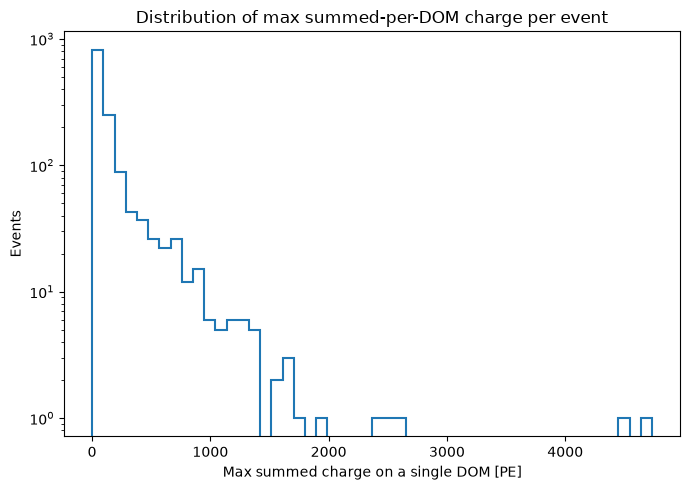

In [15]:
# Sum charge per DOM per event, then take the max DOM per event
charge_per_dom_all = df_pulses.groupby(['event_no', 'dom_x', 'dom_y', 'dom_z'])['charge'].sum().reset_index()
max_dom_charge_per_event = charge_per_dom_all.groupby('event_no')['charge'].max()

print(f"{len(max_dom_charge_per_event)} / {df_reco['event_no'].nunique()} events")
# Histogram
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(max_dom_charge_per_event, bins=50, histtype='step', linewidth=1.5)
ax.set_xlabel('Max summed charge on a single DOM [PE]')
ax.set_ylabel('Events')
ax.set_yscale('log')
ax.set_title('Distribution of max summed-per-DOM charge per event')
plt.tight_layout()
# plt.savefig('max_dom_charge_hist.png', dpi=150)
plt.show()

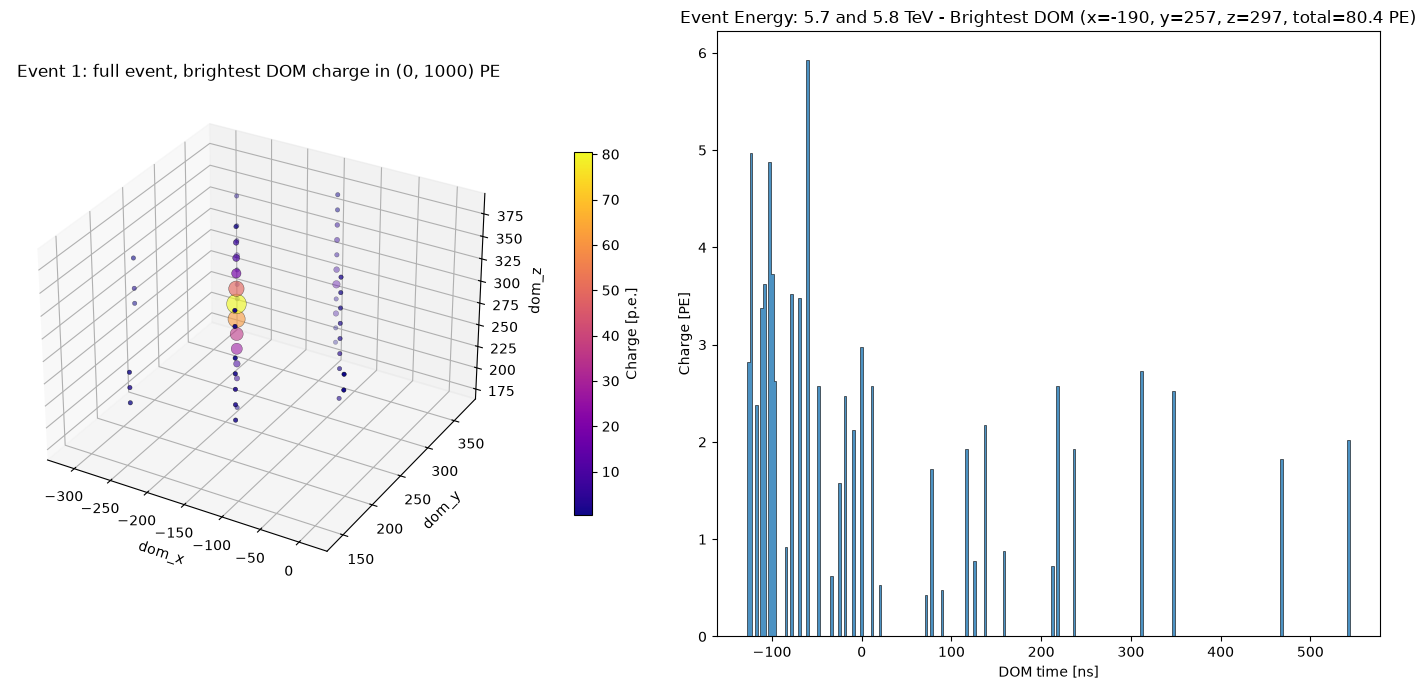

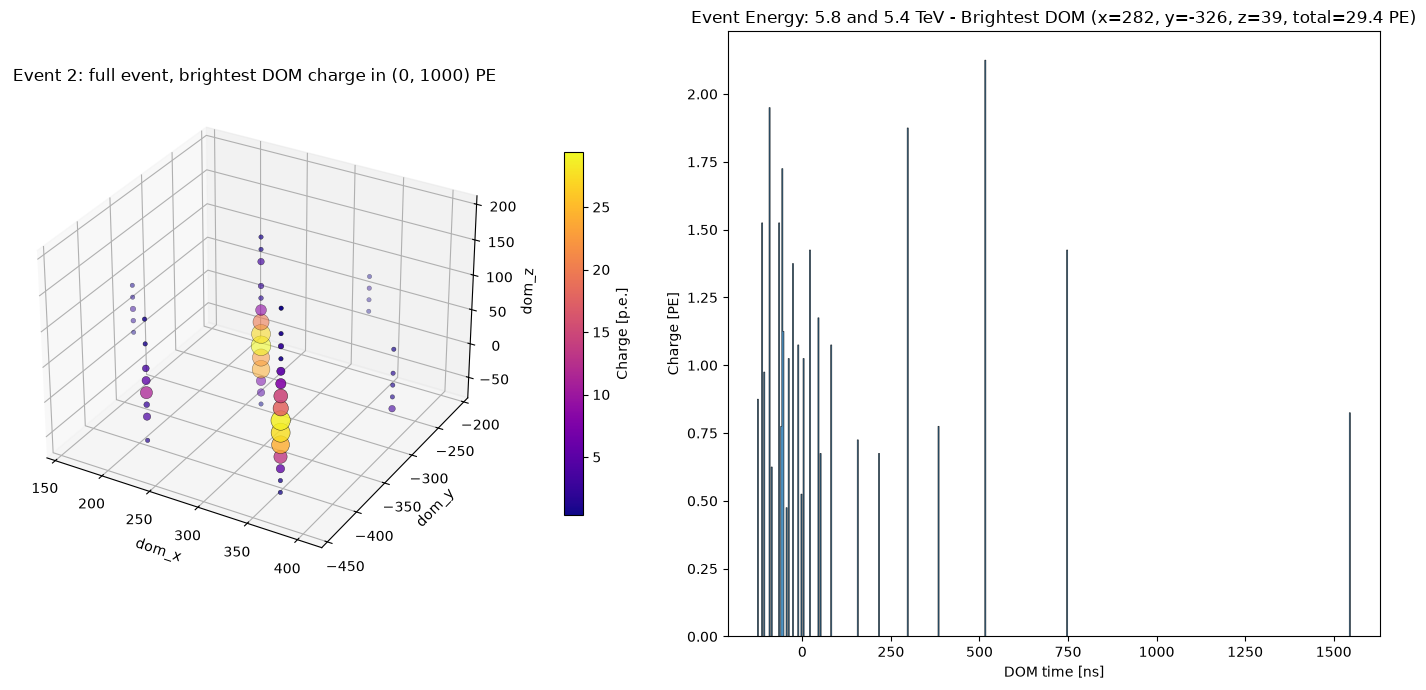

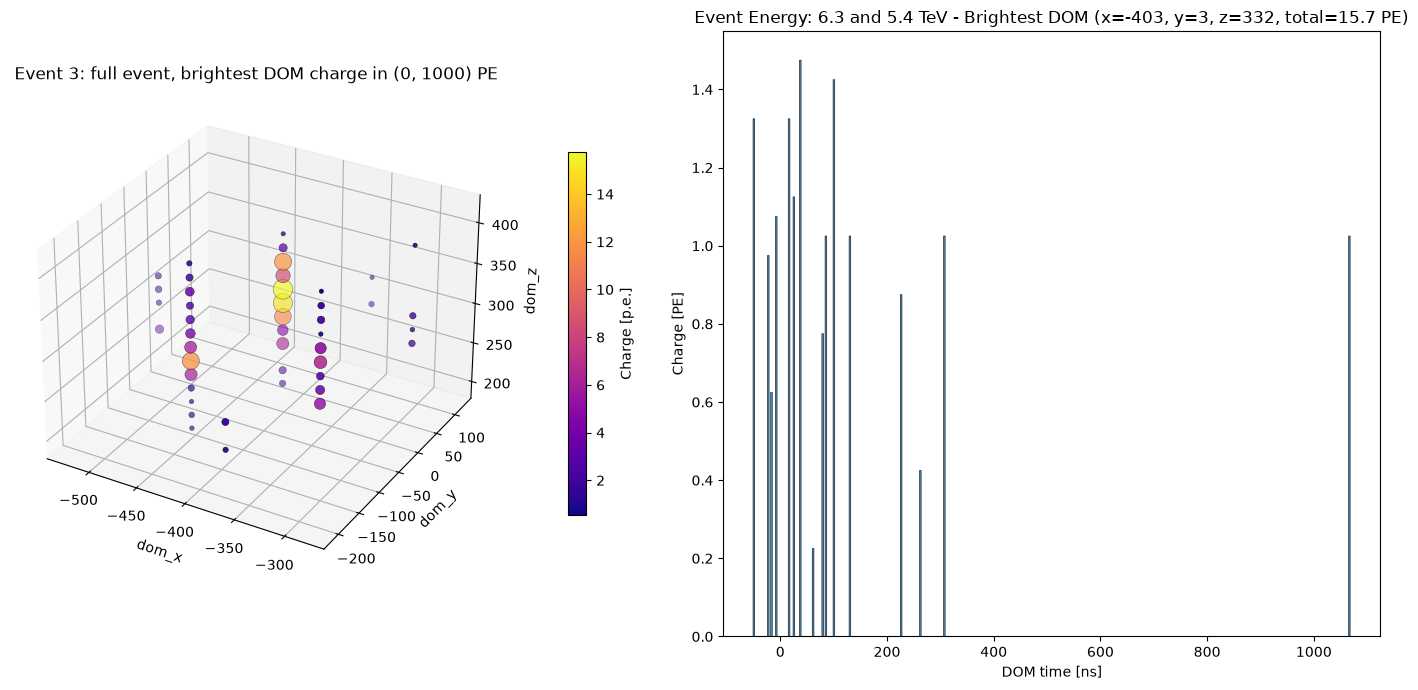

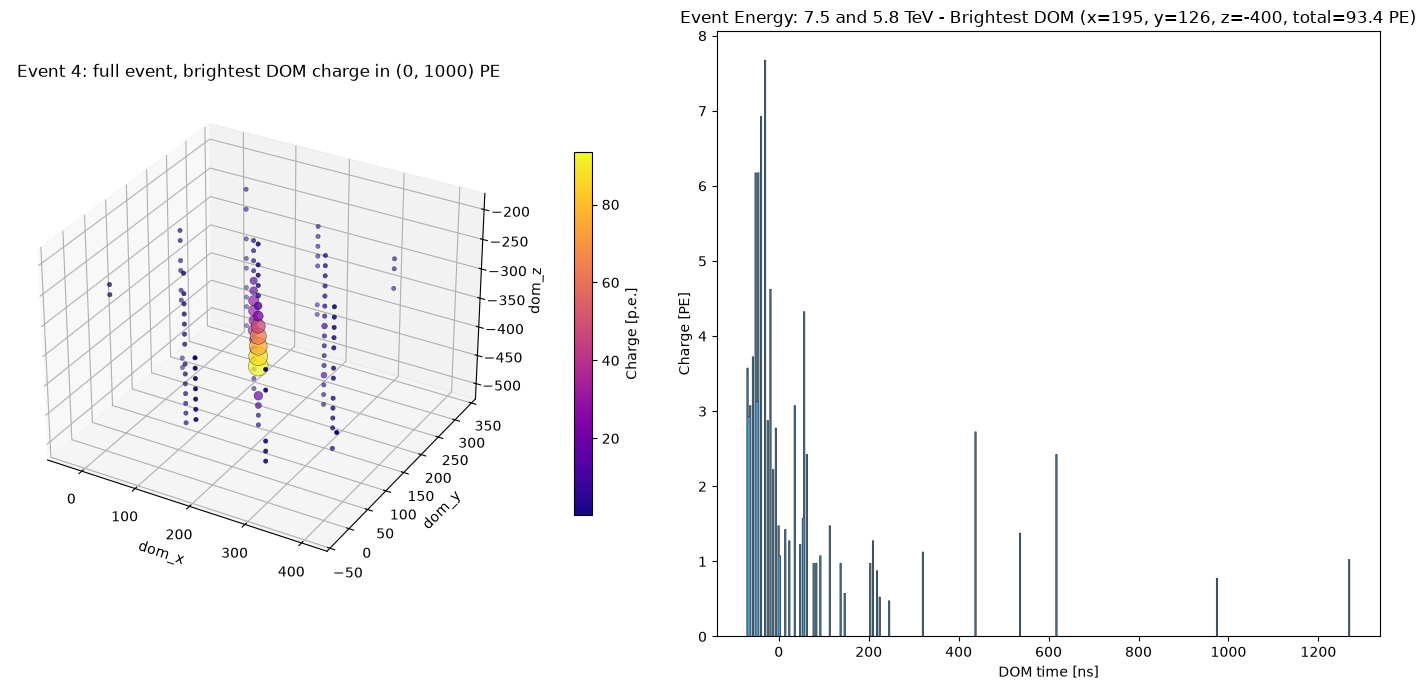

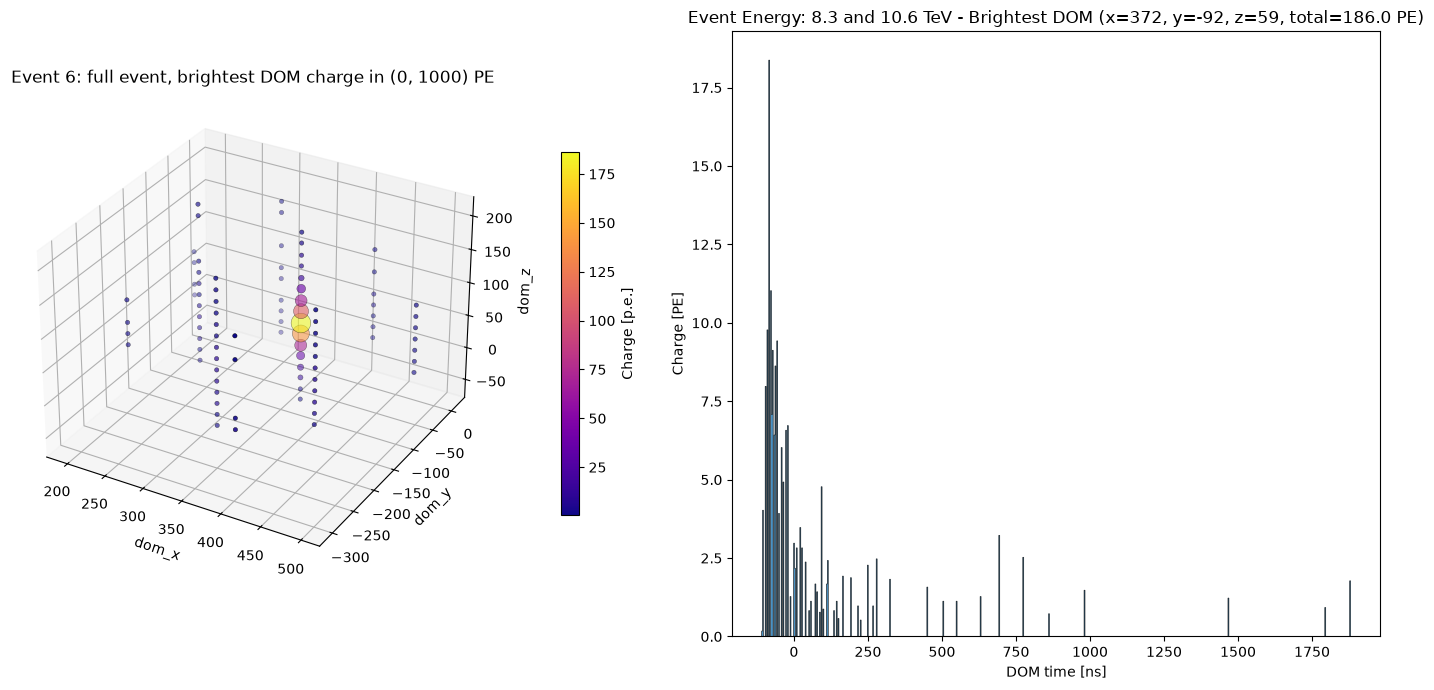

In [16]:
from matplotlib.backends.backend_pdf import PdfPages

charge_thresh_min = 0
charge_thresh_max = 1000
window_length = 10000  # ns
bin_width = 3  # ns

events_to_plot = max_dom_charge_per_event.index[:5]  # or reuse your existing event selection

with PdfPages('100-1000pe_domcut.pdf') as pdf:
    for event_no in events_to_plot:
        df_event = df_pulses[df_pulses['event_no'] == event_no]
        energy = df_truth[df_truth['event_no'] == event_no]['energy'].values[0]
        reco_energy = df_reco[df_reco['event_no'] == event_no]['cascade_reco_energy_tev'].values[0]

        # Sum charge per DOM over the FULL event (no time window / no DOM filtering)
        charge_per_dom = df_event.groupby(['dom_x', 'dom_y', 'dom_z'])['charge'].sum().reset_index()

        if charge_per_dom.empty:
            continue

        # Selection is applied only to the brightest DOM
        brightest_dom = charge_per_dom.loc[charge_per_dom['charge'].idxmax()]
        if not (charge_thresh_min < brightest_dom['charge'] < charge_thresh_max):
            continue

        bx, by, bz = brightest_dom['dom_x'], brightest_dom['dom_y'], brightest_dom['dom_z']
        dom_pulses = df_event[
            (df_event['dom_x'] == bx) &
            (df_event['dom_y'] == by) &
            (df_event['dom_z'] == bz)
        ].sort_values('dom_time')

        # Plot ALL DOMs in the event, not just the selected one
        x, y, z, charge = (charge_per_dom['dom_x'], charge_per_dom['dom_y'],
                            charge_per_dom['dom_z'], charge_per_dom['charge'])

        fig = plt.figure(figsize=(14, 7))

        ax = fig.add_subplot(121, projection='3d')
        im = ax.scatter(x, y, z, c=charge, s=np.clip(charge / charge.max() * 200, 10, 200),
                         cmap='plasma', edgecolors='k', linewidths=0.3, zorder=100)
        # ax.scatter(geo['dom_x'], geo['dom_y'], geo['dom_z'], c='lightgray', s=4, alpha=0.15, zorder=1)
        ax.set_xlabel('dom_x')
        ax.set_ylabel('dom_y')
        ax.set_zlabel('dom_z')
        ax.set_title(f'Event {event_no}: full event, brightest DOM charge in '
                     f'({charge_thresh_min}, {charge_thresh_max}) PE')
        cbar = plt.colorbar(im, ax=ax, shrink=0.6, pad=0.1)
        cbar.set_label('Charge [p.e.]')

        # Right: charge vs time histogram on brightest DOM
        ax2 = fig.add_subplot(122)
        t_min, t_max = dom_pulses['dom_time'].min(), dom_pulses['dom_time'].max()
        bins = np.arange(t_min, t_max + bin_width, bin_width)
        ax2.hist(dom_pulses['dom_time'], bins=bins, weights=dom_pulses['charge'],
                 histtype='stepfilled', edgecolor='k', linewidth=0.5, alpha=0.8)
        ax2.set_xlabel('DOM time [ns]')
        ax2.set_ylabel('Charge [PE]')
        ax2.set_title(f'Event Energy: {energy/1e3:.1f} and {reco_energy:.1f} TeV - '
                      f'Brightest DOM (x={bx:.0f}, y={by:.0f}, z={bz:.0f}, total={brightest_dom["charge"]:.1f} PE)')

        pdf.savefig(fig)
        plt.tight_layout()
        plt.show()

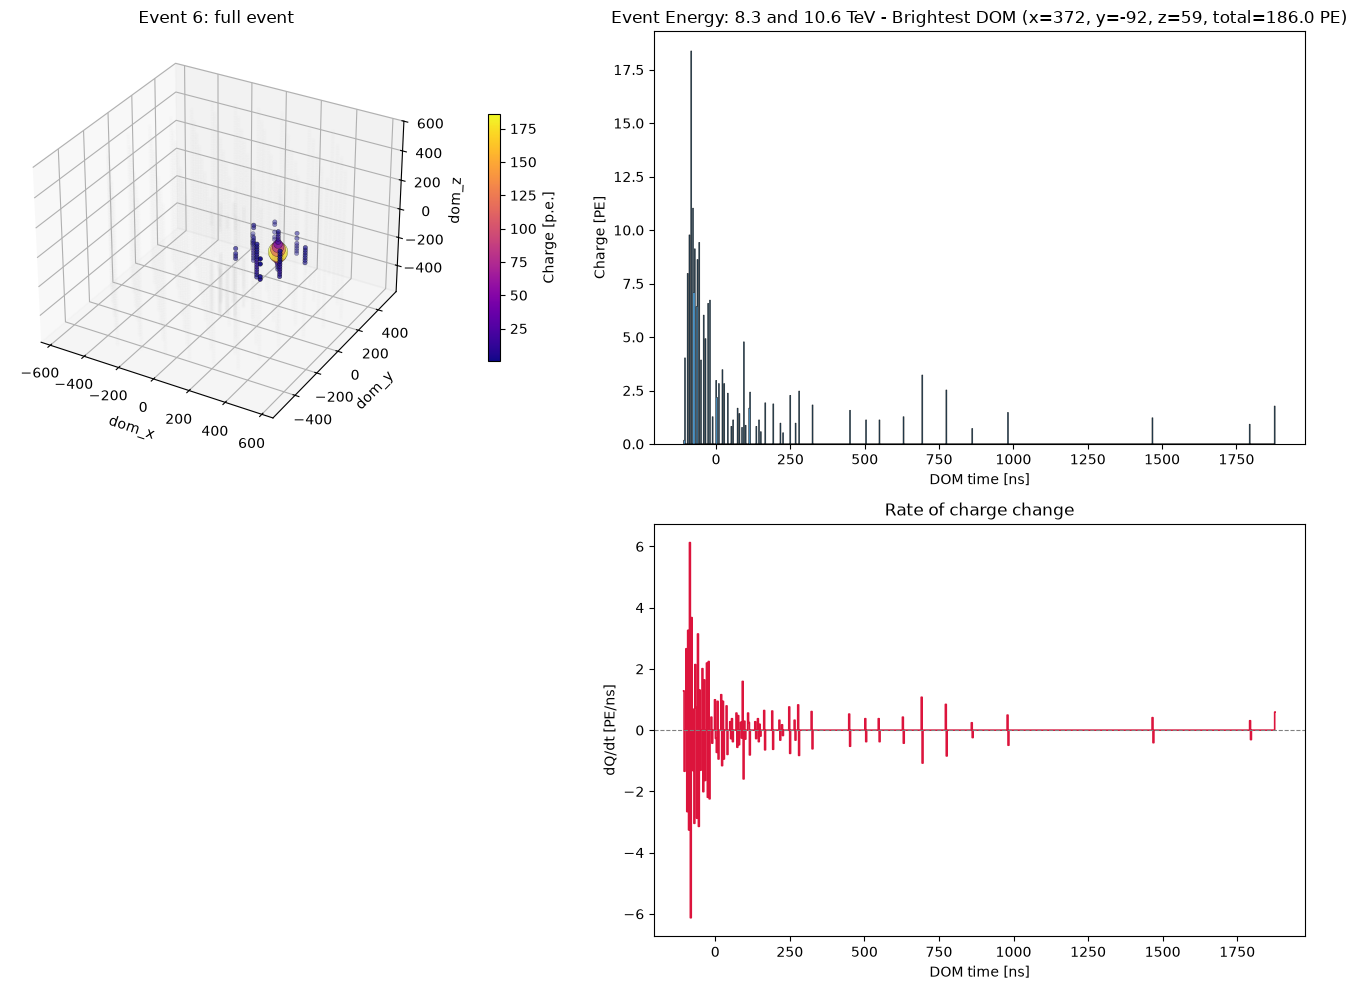

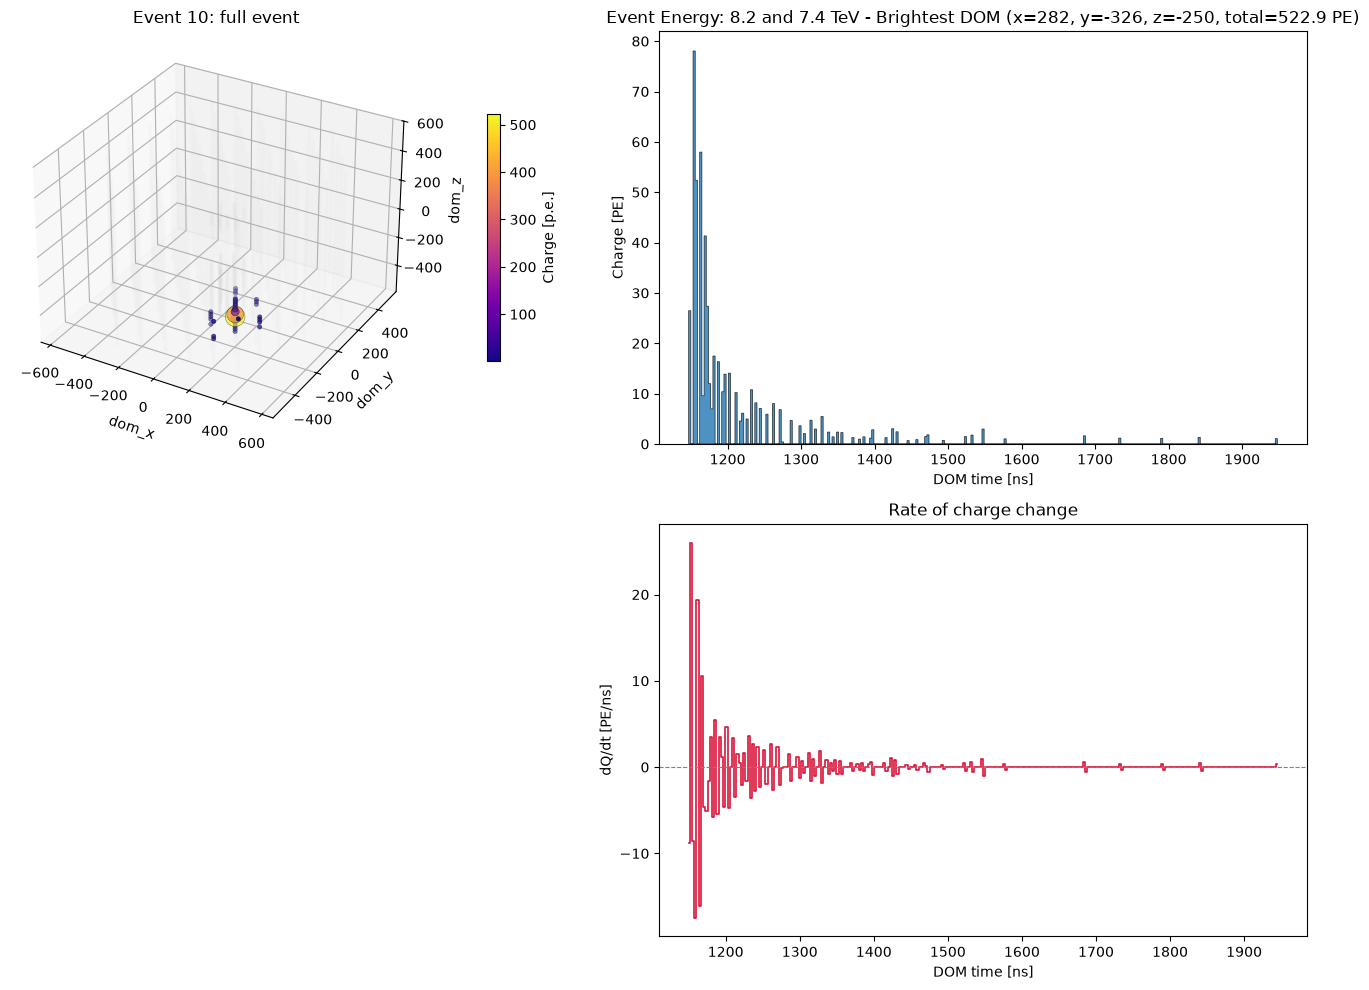

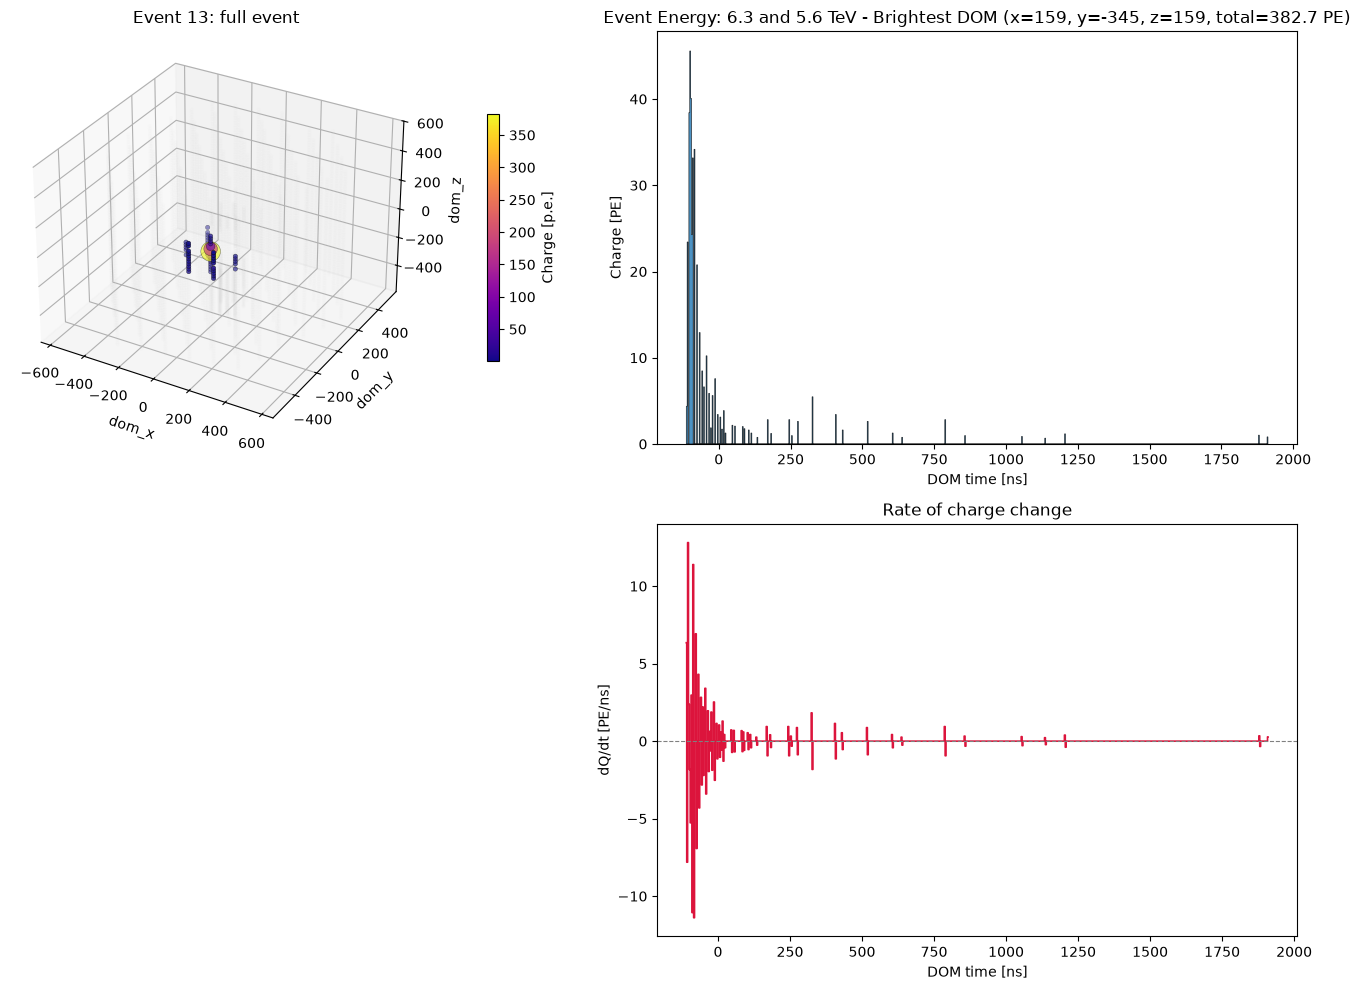

In [17]:
from matplotlib.backends.backend_pdf import PdfPages

charge_thresh_min = 100
charge_thresh_max = 10000
window_length = 10000  # ns
bin_width = 3  # ns

events_to_plot = max_dom_charge_per_event.index[:10]  # or reuse your existing event selection

with PdfPages('100-1000pe_domcut.pdf') as pdf:
    for event_no in events_to_plot:
        df_event = df_pulses[df_pulses['event_no'] == event_no]
        energy = df_truth[df_truth['event_no'] == event_no]['energy'].values[0]
        reco_energy = df_reco[df_reco['event_no'] == event_no]['cascade_reco_energy_tev'].values[0]

        # Sum charge per DOM over the FULL event (no time window / no DOM filtering)
        charge_per_dom = df_event.groupby(['dom_x', 'dom_y', 'dom_z'])['charge'].sum().reset_index()

        if charge_per_dom.empty:
            continue

        # Selection is applied only to the brightest DOM
        brightest_dom = charge_per_dom.loc[charge_per_dom['charge'].idxmax()]
        if not (charge_thresh_min < brightest_dom['charge'] < charge_thresh_max):
            continue

        bx, by, bz = brightest_dom['dom_x'], brightest_dom['dom_y'], brightest_dom['dom_z']
        dom_pulses = df_event[
            (df_event['dom_x'] == bx) &
            (df_event['dom_y'] == by) &
            (df_event['dom_z'] == bz)
        ].sort_values('dom_time')

        # Plot ALL DOMs in the event, not just the selected one
        x, y, z, charge = (charge_per_dom['dom_x'], charge_per_dom['dom_y'],
                            charge_per_dom['dom_z'], charge_per_dom['charge'])

        fig = plt.figure(figsize=(14, 10))

        ax = fig.add_subplot(221, projection='3d')
        im = ax.scatter(x, y, z, c=charge, s=np.clip(charge / charge.max() * 200, 10, 200),
                        cmap='plasma', edgecolors='k', linewidths=0.3, zorder=100)
        ax.scatter(geo['dom_x'], geo['dom_y'], geo['dom_z'], c='lightgray', s=4, alpha=0.15, zorder=1)
        ax.set_xlabel('dom_x'); ax.set_ylabel('dom_y'); ax.set_zlabel('dom_z')
        ax.set_title(f'Event {event_no}: full event')
        plt.colorbar(im, ax=ax, shrink=0.6, pad=0.1).set_label('Charge [p.e.]')

        t_min, t_max = dom_pulses['dom_time'].min(), dom_pulses['dom_time'].max()
        bins = np.arange(t_min, t_max + bin_width, bin_width)
        charge_binned, bin_edges = np.histogram(dom_pulses['dom_time'], bins=bins, weights=dom_pulses['charge'])
        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

        # Charge histogram
        ax2 = fig.add_subplot(222)
        ax2.hist(dom_pulses['dom_time'], bins=bins, weights=dom_pulses['charge'],
                histtype='stepfilled', edgecolor='k', linewidth=0.5, alpha=0.8)
        ax2.set_xlabel('DOM time [ns]')
        ax2.set_ylabel('Charge [PE]')
        ax2.set_title(f'Event Energy: {energy/1e3:.1f} and {reco_energy:.1f} TeV - '
                      f'Brightest DOM (x={bx:.0f}, y={by:.0f}, z={bz:.0f}, total={brightest_dom["charge"]:.1f} PE)')

        # Rate of change of charge
        ax3 = fig.add_subplot(224)
        dQ_dt = np.diff(charge_binned) / bin_width
        dQ_dt_centers = 0.5 * (bin_centers[:-1] + bin_centers[1:])
        ax3.plot(dQ_dt_centers, dQ_dt, drawstyle='steps-mid', color='crimson', linewidth=1.2)
        ax3.axhline(0, color='gray', linewidth=0.8, linestyle='--')
        ax3.set_xlabel('DOM time [ns]')
        ax3.set_ylabel('dQ/dt [PE/ns]')
        ax3.set_title('Rate of charge change')

        pdf.savefig(fig)
        plt.tight_layout()
        plt.show()
        plt.close(fig)

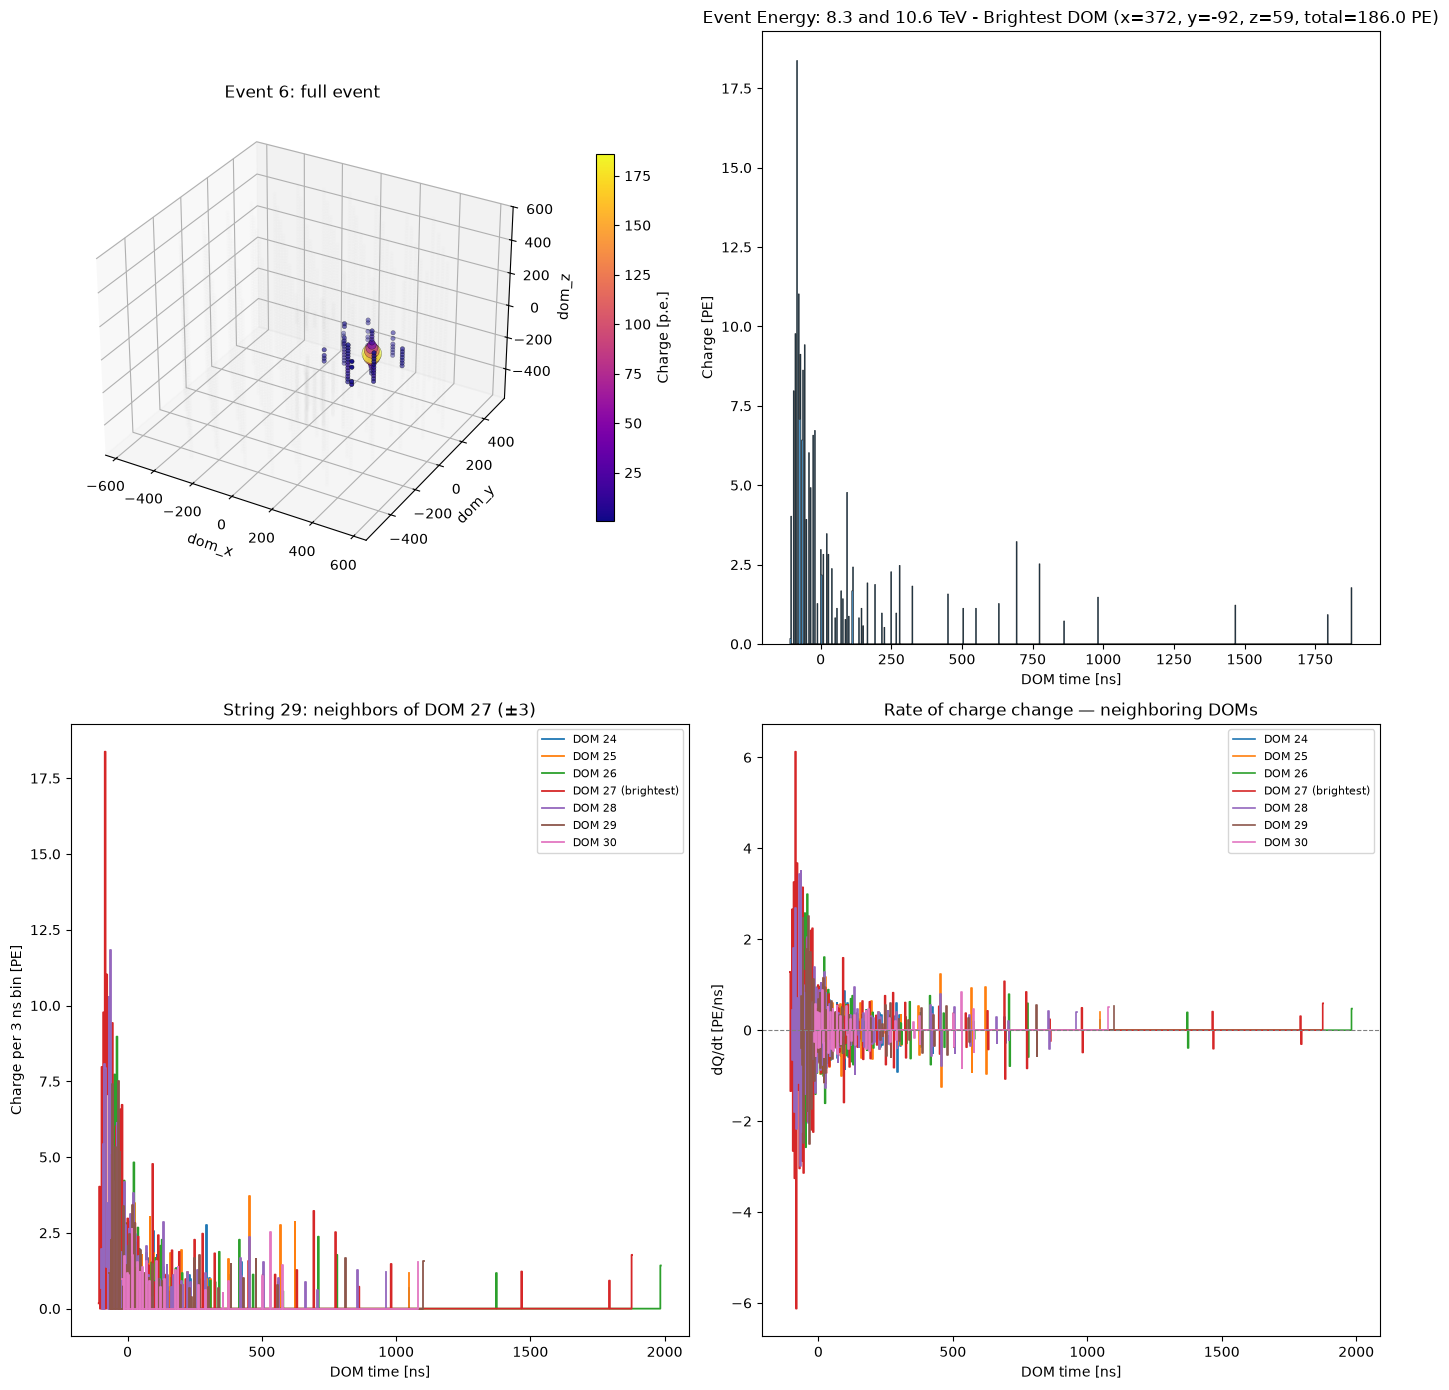

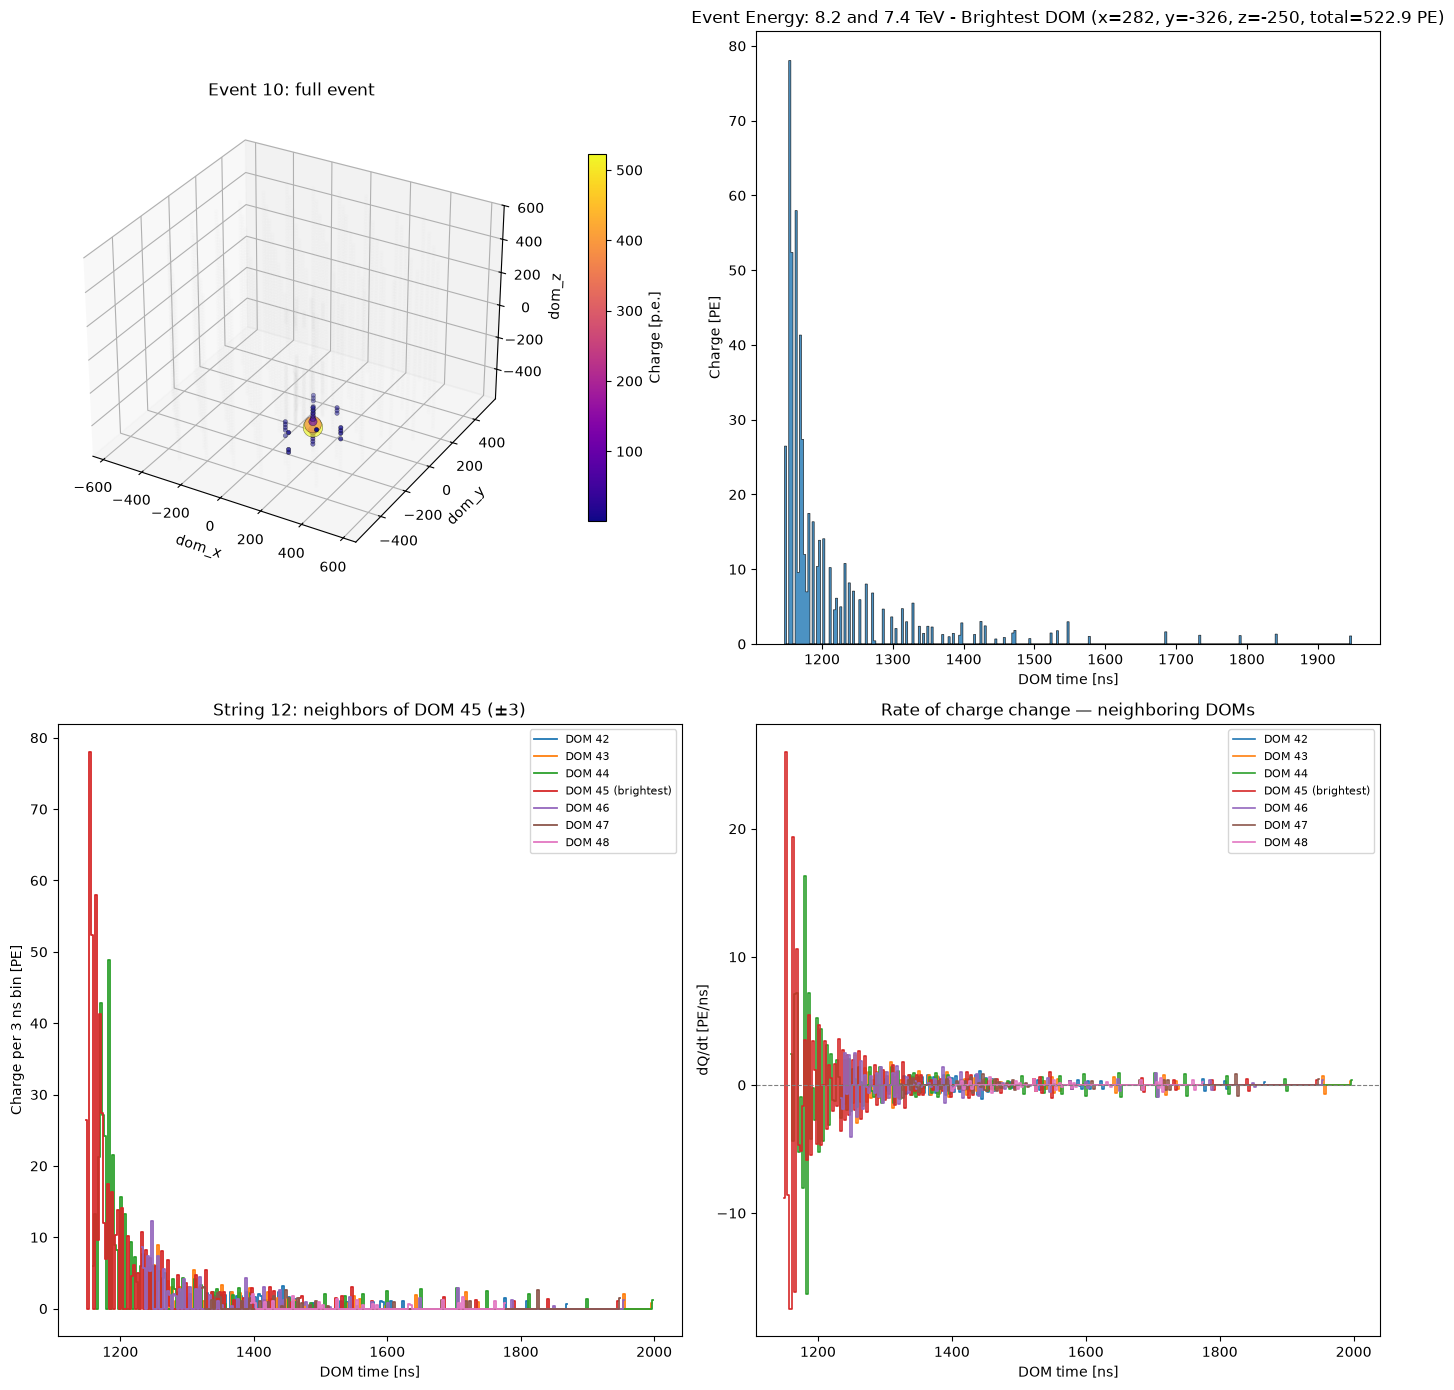

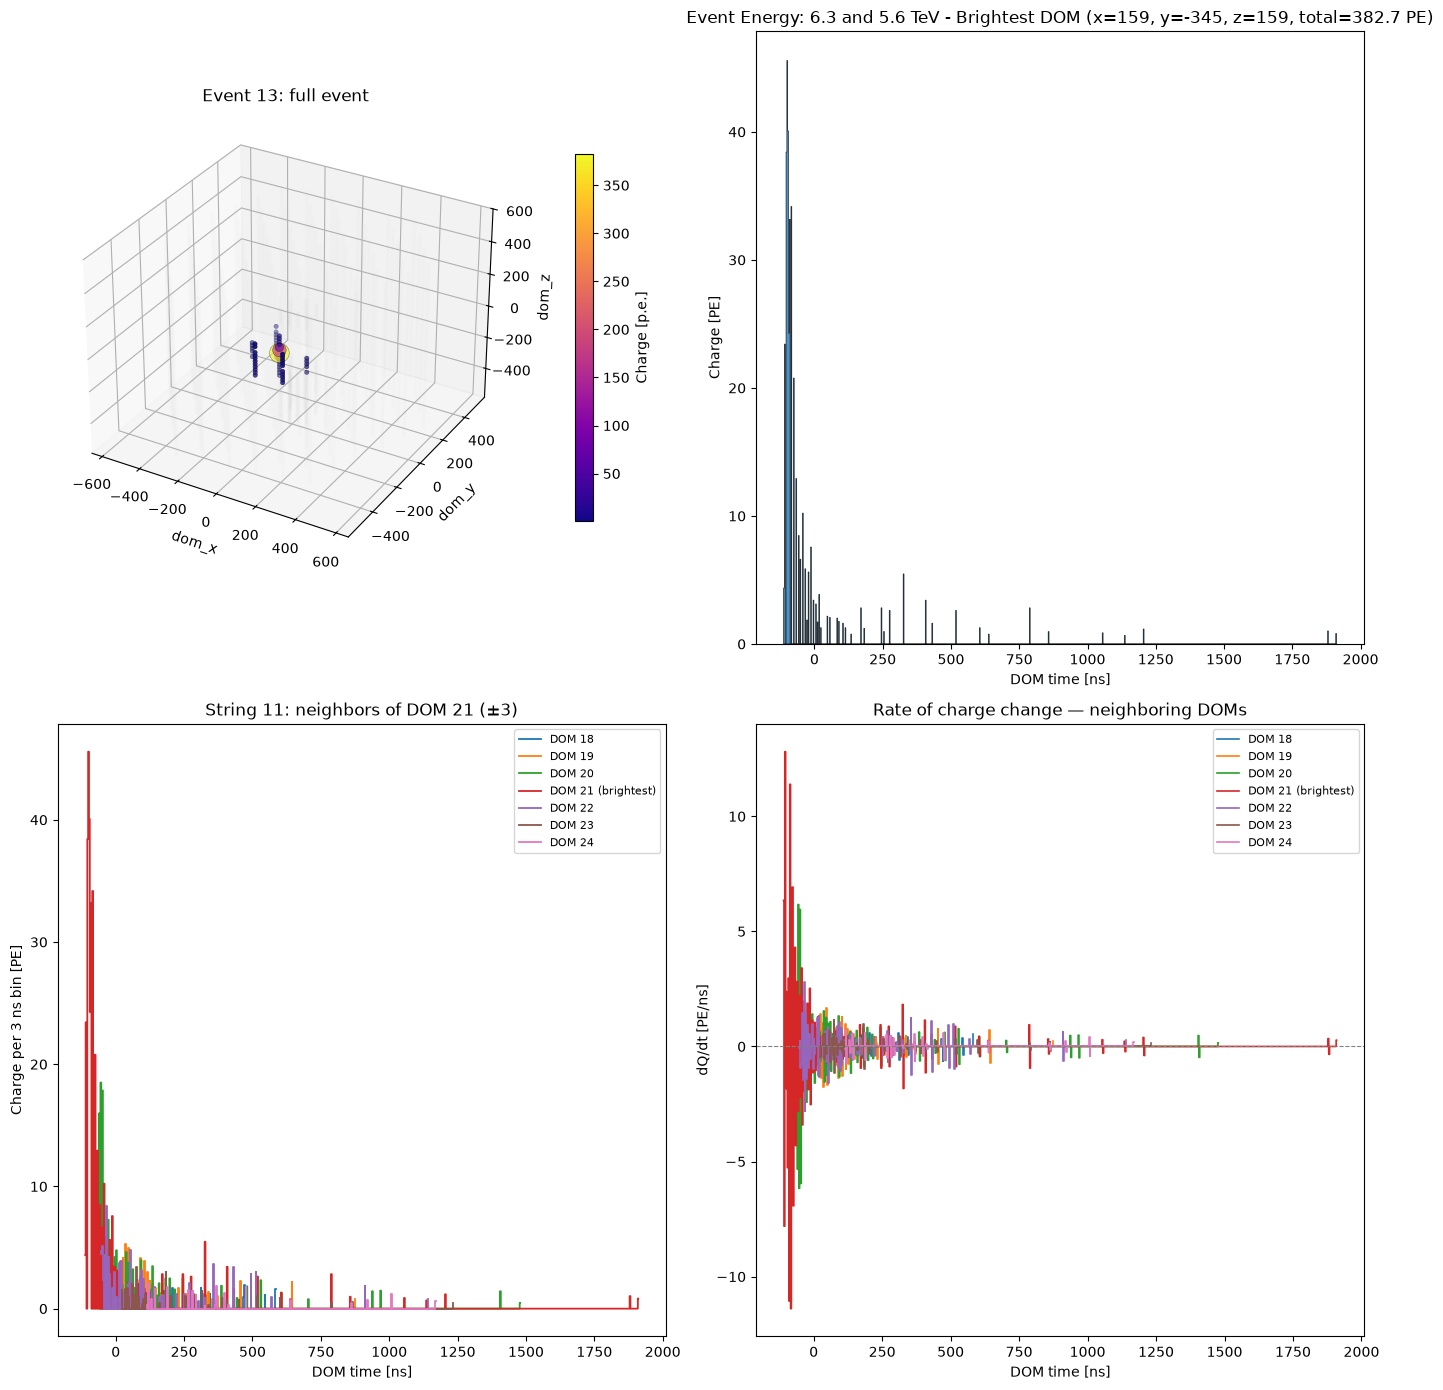

In [18]:
from matplotlib.backends.backend_pdf import PdfPages

charge_thresh_min = 100
charge_thresh_max = 10000
window_length = 10000  # ns
bin_width = 3  # ns
n_neighbors = 3  # DOMs above/below the brightest one on the string

events_to_plot = max_dom_charge_per_event.index[:10]  # or reuse your existing event selection

with PdfPages('100-1000pe_domcut.pdf') as pdf:
    for event_no in events_to_plot:
        df_event = df_pulses[df_pulses['event_no'] == event_no]
        energy = df_truth[df_truth['event_no'] == event_no]['energy'].values[0]
        reco_energy = df_reco[df_reco['event_no'] == event_no]['cascade_reco_energy_tev'].values[0]

        # Sum charge per DOM over the FULL event (no time window / no DOM filtering)
        charge_per_dom = df_event.groupby(['dom_x', 'dom_y', 'dom_z'])['charge'].sum().reset_index()

        if charge_per_dom.empty:
            continue

        # Selection is applied only to the brightest DOM
        brightest_dom = charge_per_dom.loc[charge_per_dom['charge'].idxmax()]
        if not (charge_thresh_min < brightest_dom['charge'] < charge_thresh_max):
            continue

        bx, by, bz = brightest_dom['dom_x'], brightest_dom['dom_y'], brightest_dom['dom_z']
        dom_pulses = df_event[
            (df_event['dom_x'] == bx) &
            (df_event['dom_y'] == by) &
            (df_event['dom_z'] == bz)
        ].sort_values('dom_time')

        # Attach string/dom_no to this event's pulses, and find neighbors of the brightest DOM
        pulses_with_domno = df_event.merge(
            geo[['dom_x', 'dom_y', 'dom_z', 'string', 'dom_no']],
            on=['dom_x', 'dom_y', 'dom_z'], how='left'
        )
        brightest_geo_row = geo[
            (geo['dom_x'] == bx) & (geo['dom_y'] == by) & (geo['dom_z'] == bz)
        ].iloc[0]
        b_string, b_dom_no = brightest_geo_row['string'], brightest_geo_row['dom_no']
        neighbor_range = range(int(b_dom_no - n_neighbors), int(b_dom_no + n_neighbors + 1))
        neighbor_pulses = pulses_with_domno[
            (pulses_with_domno['string'] == b_string) &
            (pulses_with_domno['dom_no'].isin(neighbor_range))
        ]

        # Plot ALL DOMs in the event, not just the selected one
        x, y, z, charge = (charge_per_dom['dom_x'], charge_per_dom['dom_y'],
                            charge_per_dom['dom_z'], charge_per_dom['charge'])

        fig = plt.figure(figsize=(14, 14))

        # Top-left: full event 3D charge map
        ax = fig.add_subplot(221, projection='3d')
        im = ax.scatter(x, y, z, c=charge, s=np.clip(charge / charge.max() * 200, 10, 200),
                        cmap='plasma', edgecolors='k', linewidths=0.3, zorder=100)
        ax.scatter(geo['dom_x'], geo['dom_y'], geo['dom_z'], c='lightgray', s=4, alpha=0.15, zorder=1)
        ax.set_xlabel('dom_x'); ax.set_ylabel('dom_y'); ax.set_zlabel('dom_z')
        ax.set_title(f'Event {event_no}: full event')
        plt.colorbar(im, ax=ax, shrink=0.6, pad=0.1).set_label('Charge [p.e.]')

        # Top-right: brightest DOM charge histogram
        t_min, t_max = dom_pulses['dom_time'].min(), dom_pulses['dom_time'].max()
        bins = np.arange(t_min, t_max + bin_width, bin_width)
        charge_binned, bin_edges = np.histogram(dom_pulses['dom_time'], bins=bins, weights=dom_pulses['charge'])
        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

        ax2 = fig.add_subplot(222)
        ax2.hist(dom_pulses['dom_time'], bins=bins, weights=dom_pulses['charge'],
                histtype='stepfilled', edgecolor='k', linewidth=0.5, alpha=0.8)
        ax2.set_xlabel('DOM time [ns]')
        ax2.set_ylabel('Charge [PE]')
        ax2.set_title(f'Event Energy: {energy/1e3:.1f} and {reco_energy:.1f} TeV - '
                      f'Brightest DOM (x={bx:.0f}, y={by:.0f}, z={bz:.0f}, total={brightest_dom["charge"]:.1f} PE)')

        # Bottom-left: charge vs time, brightest DOM + its neighbors, overlaid
        ax3 = fig.add_subplot(223)
        neighbor_bins_cache = {}  # keep binned data to reuse for dQ/dt panel
        for dom_no_val in sorted(neighbor_pulses['dom_no'].unique()):
            dp = neighbor_pulses[neighbor_pulses['dom_no'] == dom_no_val].sort_values('dom_time')
            if dp.empty:
                continue
            dt_min, dt_max = dp['dom_time'].min(), dp['dom_time'].max()
            dbins = np.arange(dt_min, dt_max + bin_width, bin_width)
            dbinned, dedges = np.histogram(dp['dom_time'], bins=dbins, weights=dp['charge'])
            dcenters = 0.5 * (dedges[:-1] + dedges[1:])
            neighbor_bins_cache[dom_no_val] = (dcenters, dbinned)
            label = f'DOM {int(dom_no_val)}' + (' (brightest)' if dom_no_val == b_dom_no else '')
            ax3.step(dcenters, dbinned, where='mid', linewidth=1.3, label=label)
        ax3.set_xlabel('DOM time [ns]')
        ax3.set_ylabel(f'Charge per {bin_width} ns bin [PE]')
        ax3.set_title(f'String {int(b_string)}: neighbors of DOM {int(b_dom_no)} (±{n_neighbors})')
        ax3.legend(fontsize=8)

        # Bottom-right: rate of charge change, all neighboring DOMs overlaid
        ax4 = fig.add_subplot(224)
        for dom_no_val, (dcenters, dbinned) in neighbor_bins_cache.items():
            if len(dbinned) < 2:
                continue
            dQ_dt = np.diff(dbinned) / bin_width
            dQ_dt_centers = 0.5 * (dcenters[:-1] + dcenters[1:])
            label = f'DOM {int(dom_no_val)}' + (' (brightest)' if dom_no_val == b_dom_no else '')
            ax4.plot(dQ_dt_centers, dQ_dt, drawstyle='steps-mid', linewidth=1.2, label=label)
        ax4.axhline(0, color='gray', linewidth=0.8, linestyle='--')
        ax4.set_xlabel('DOM time [ns]')
        ax4.set_ylabel('dQ/dt [PE/ns]')
        ax4.set_title('Rate of charge change — neighboring DOMs')
        ax4.legend(fontsize=8)

        pdf.savefig(fig)
        plt.tight_layout()
        plt.show()
        plt.close(fig)

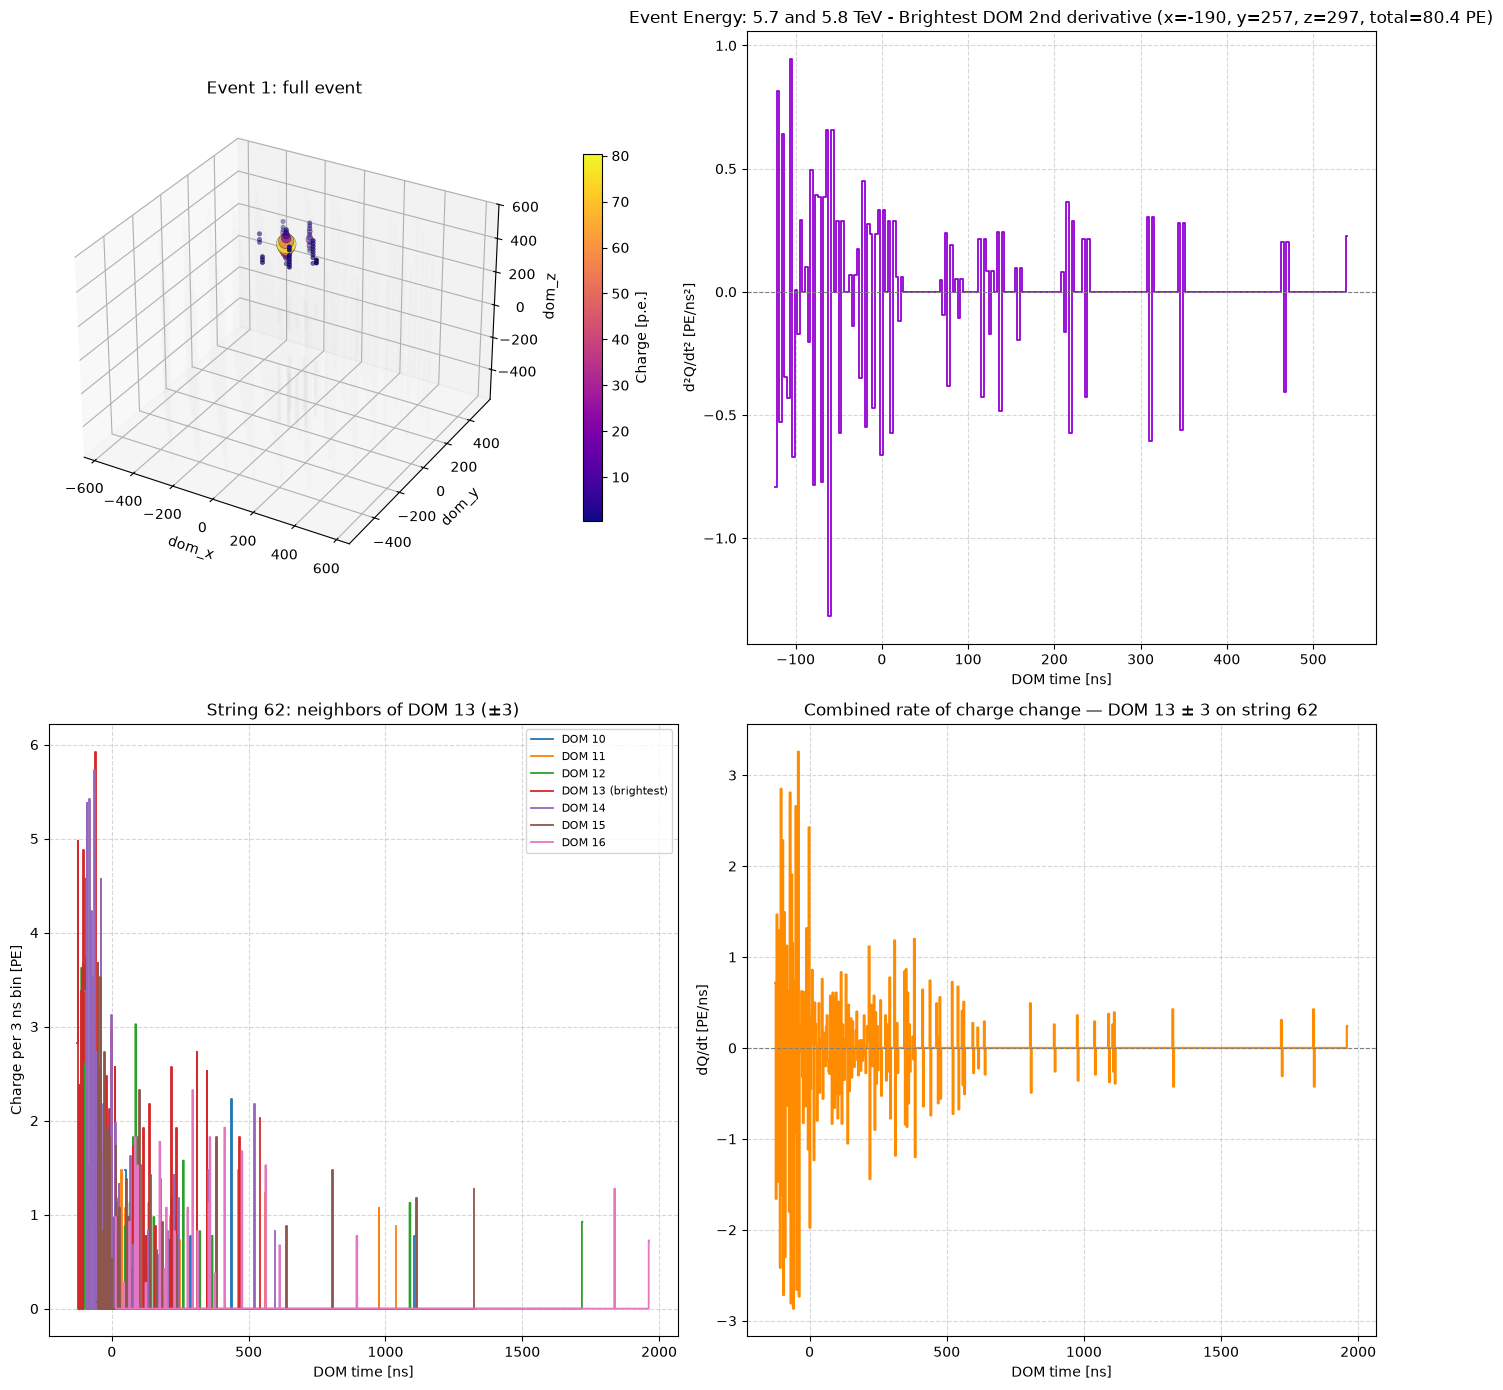

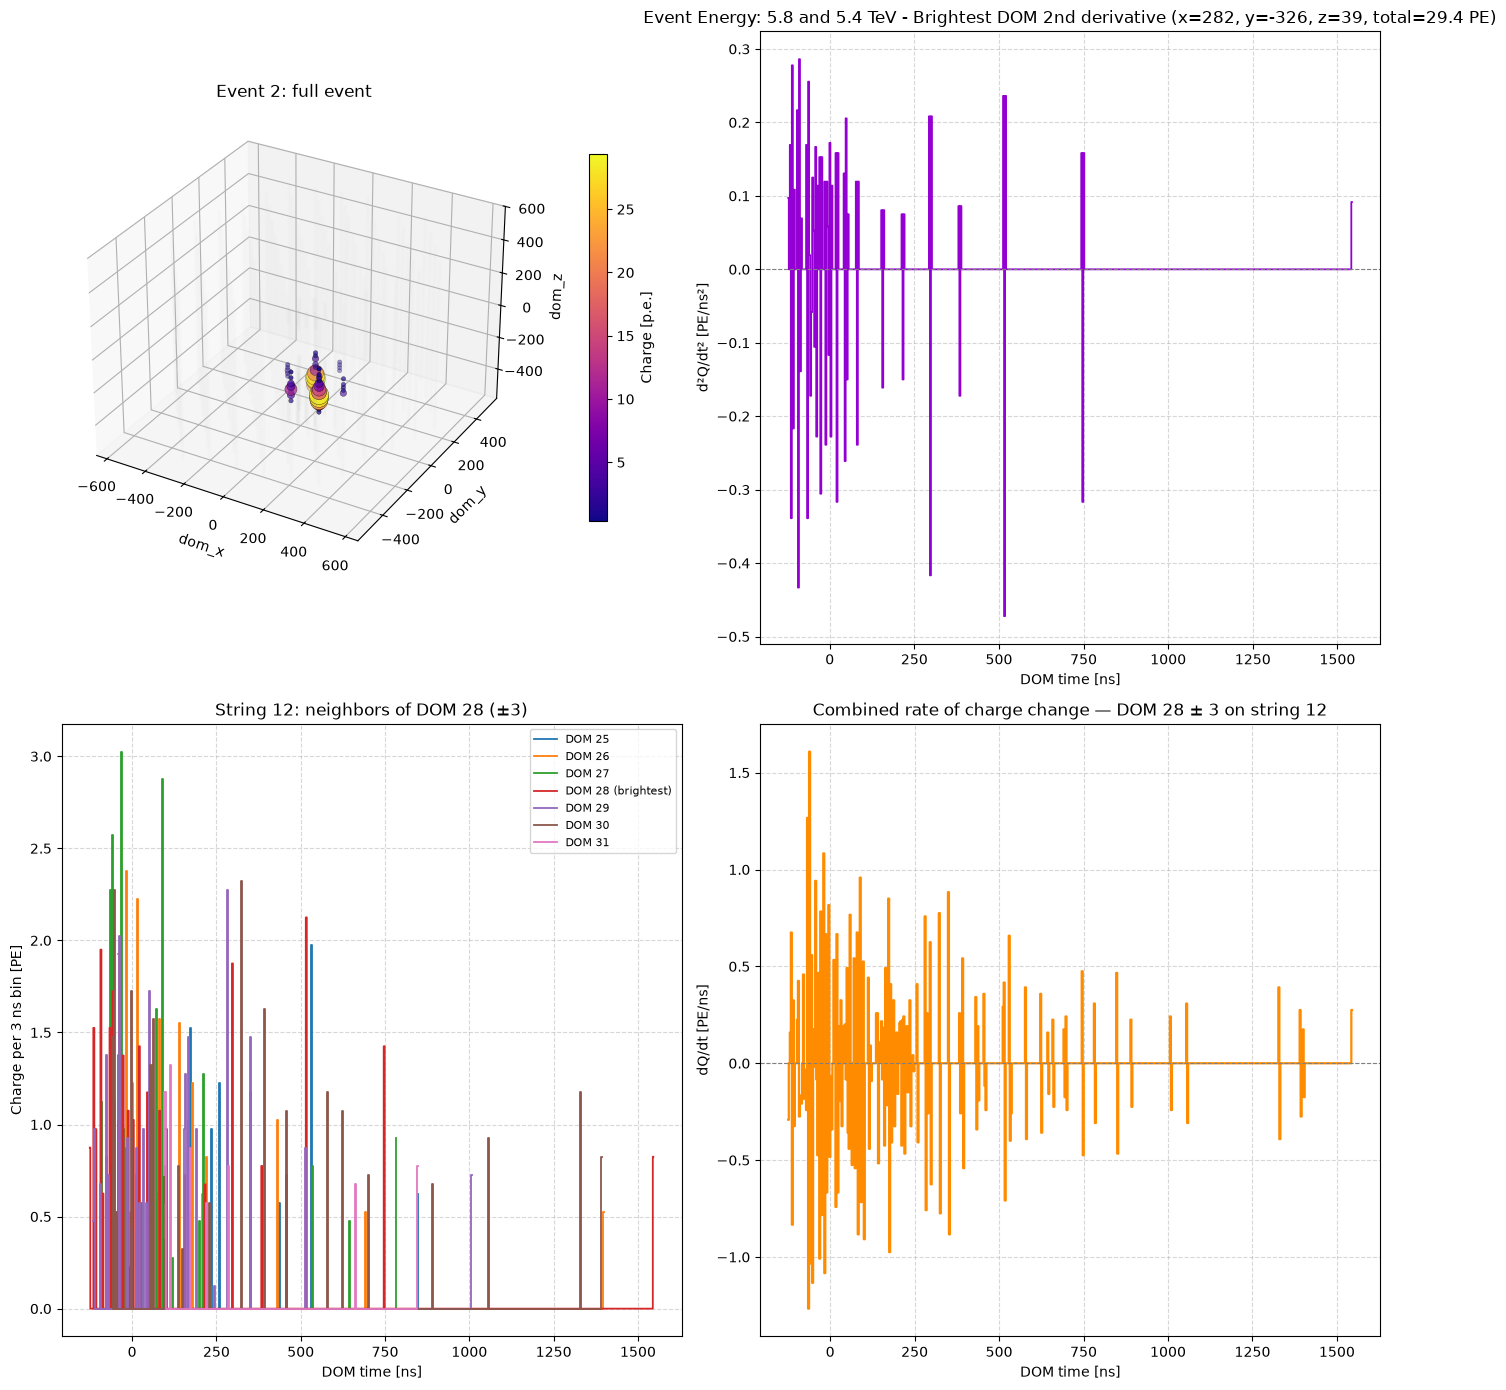

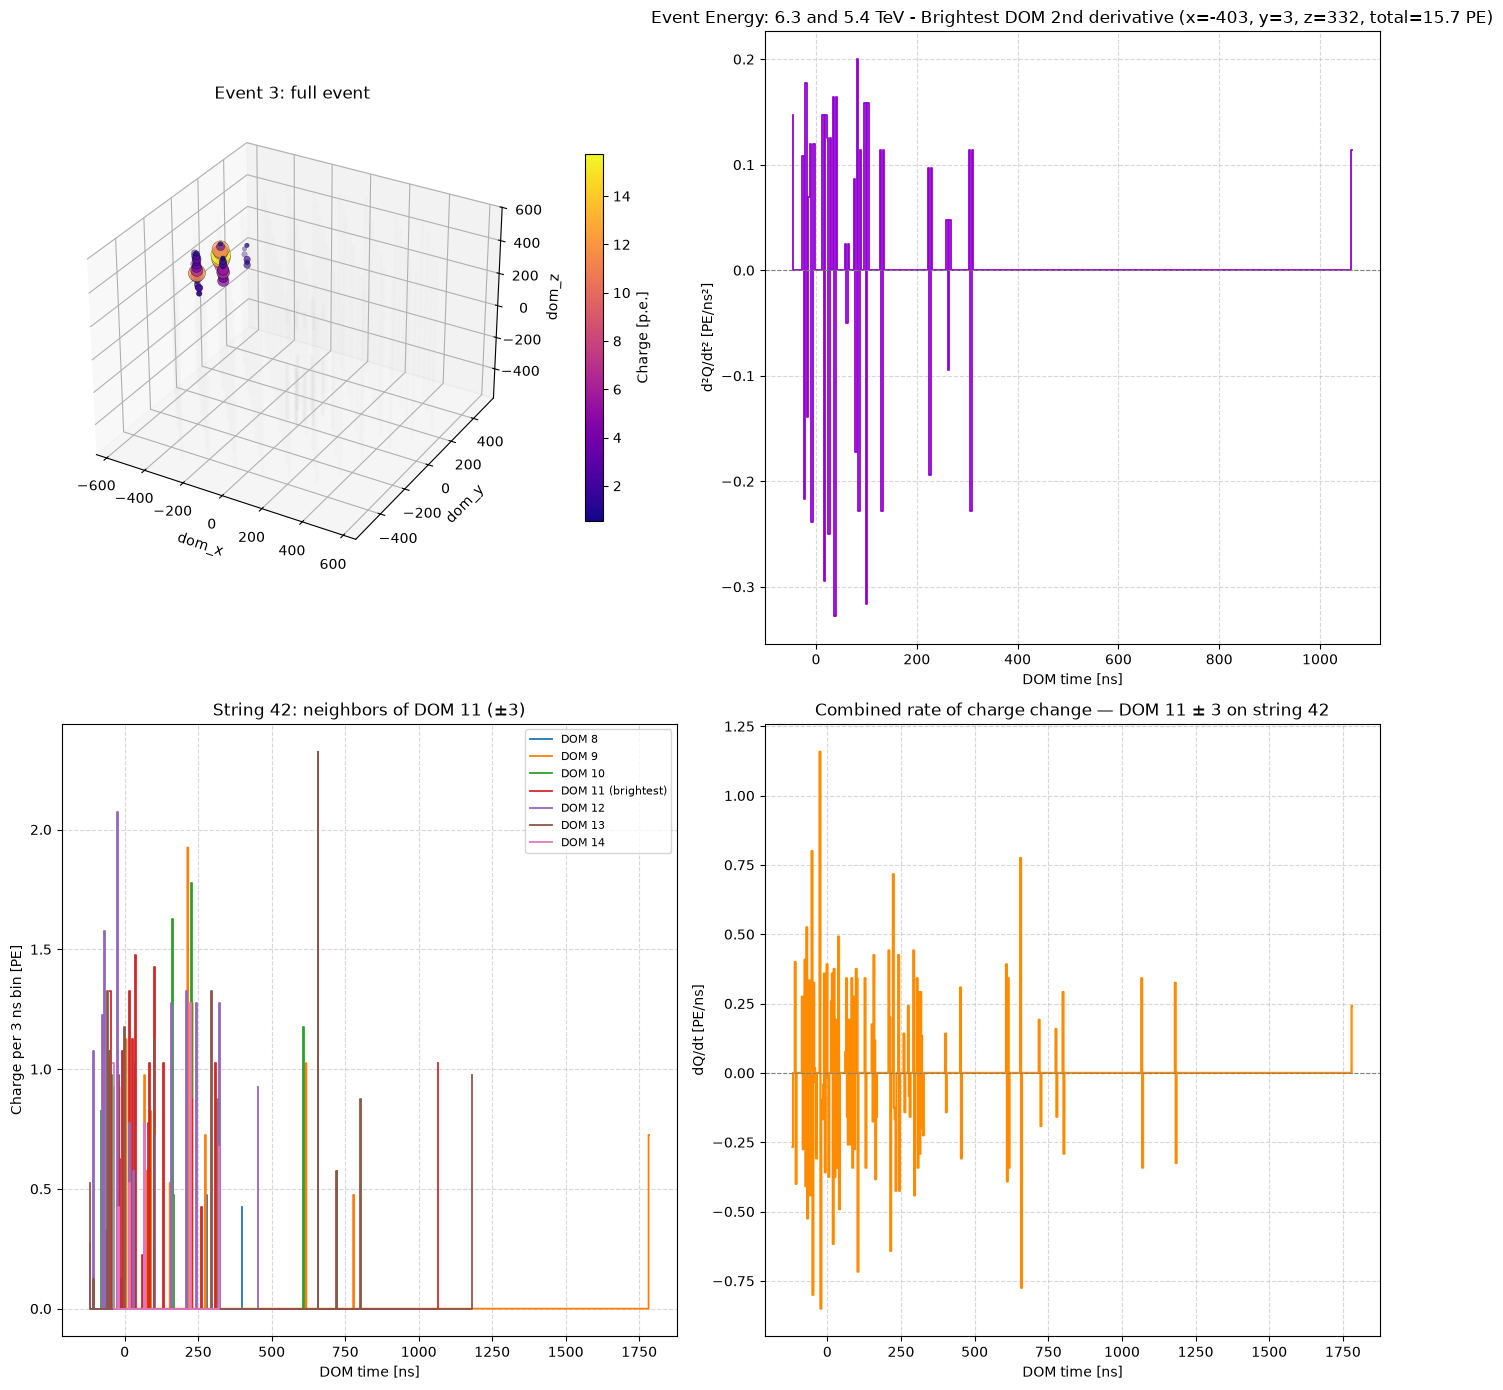

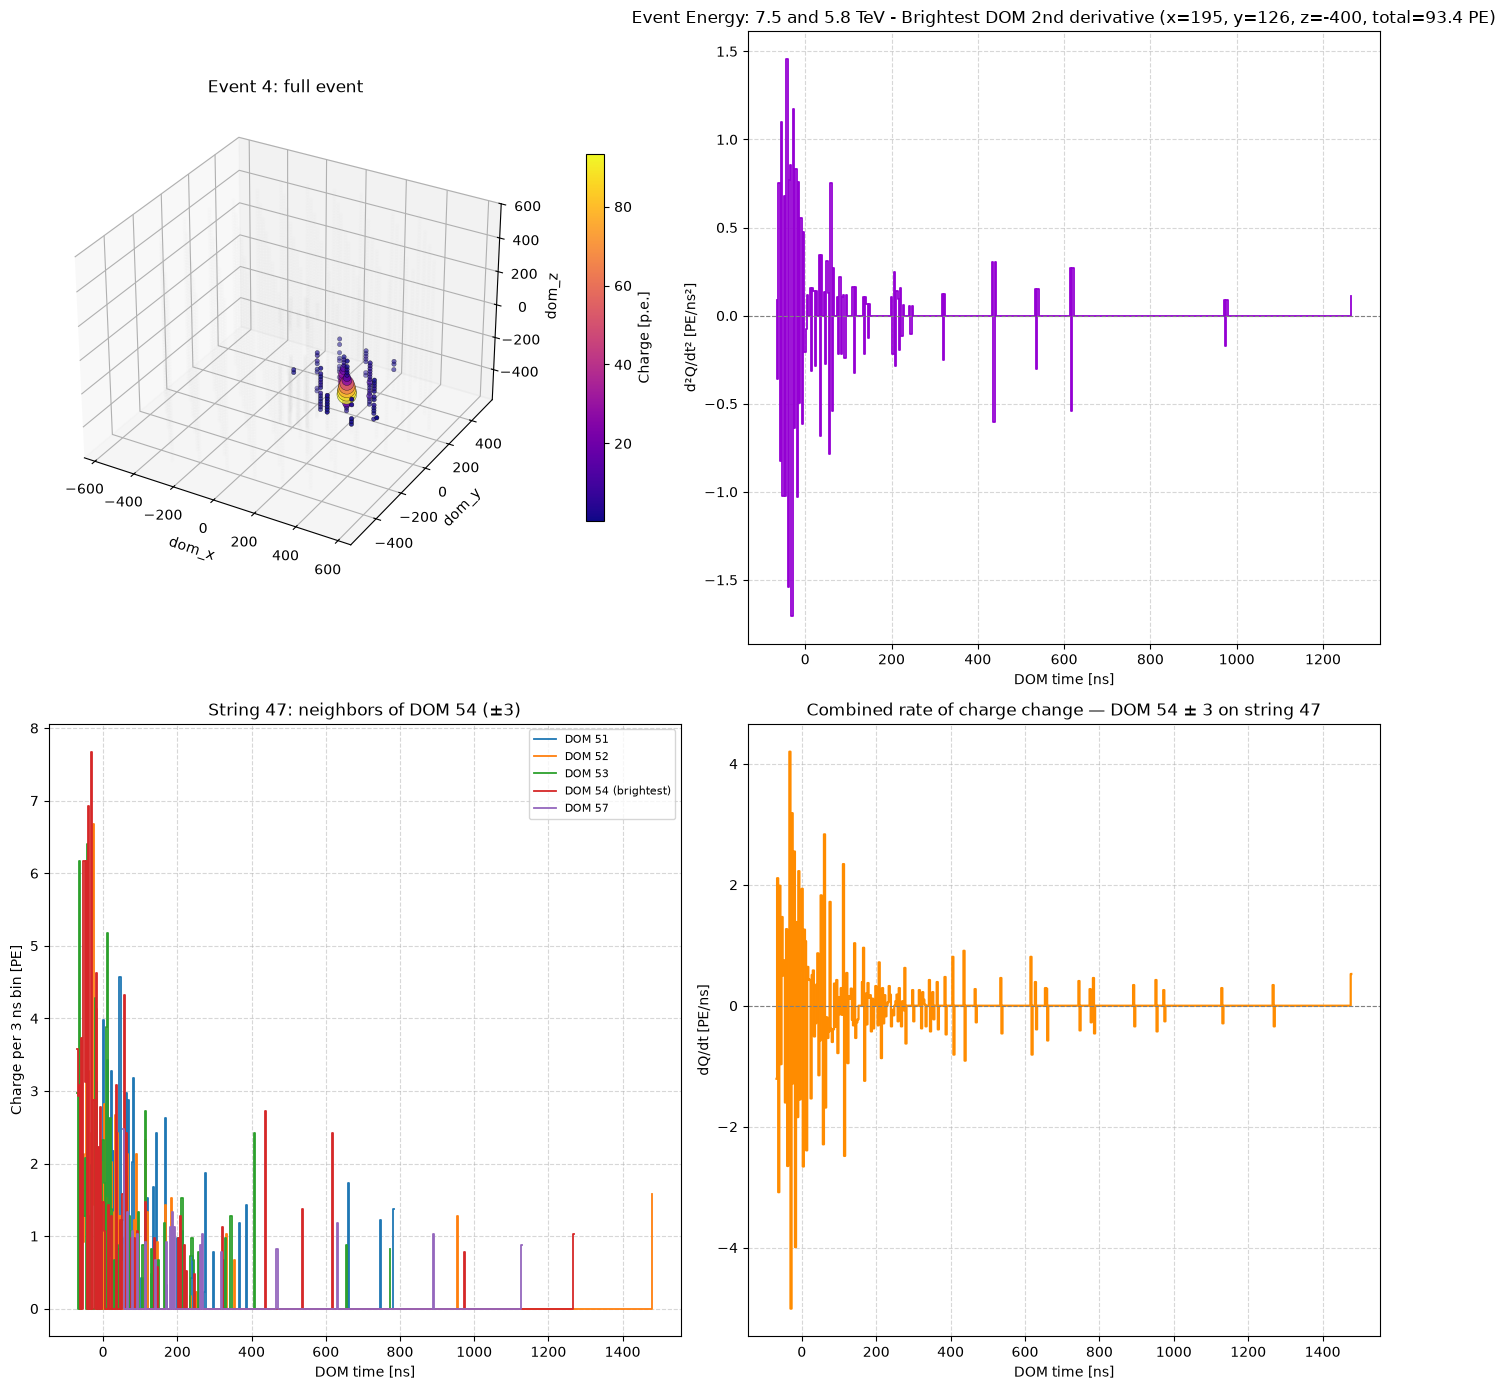

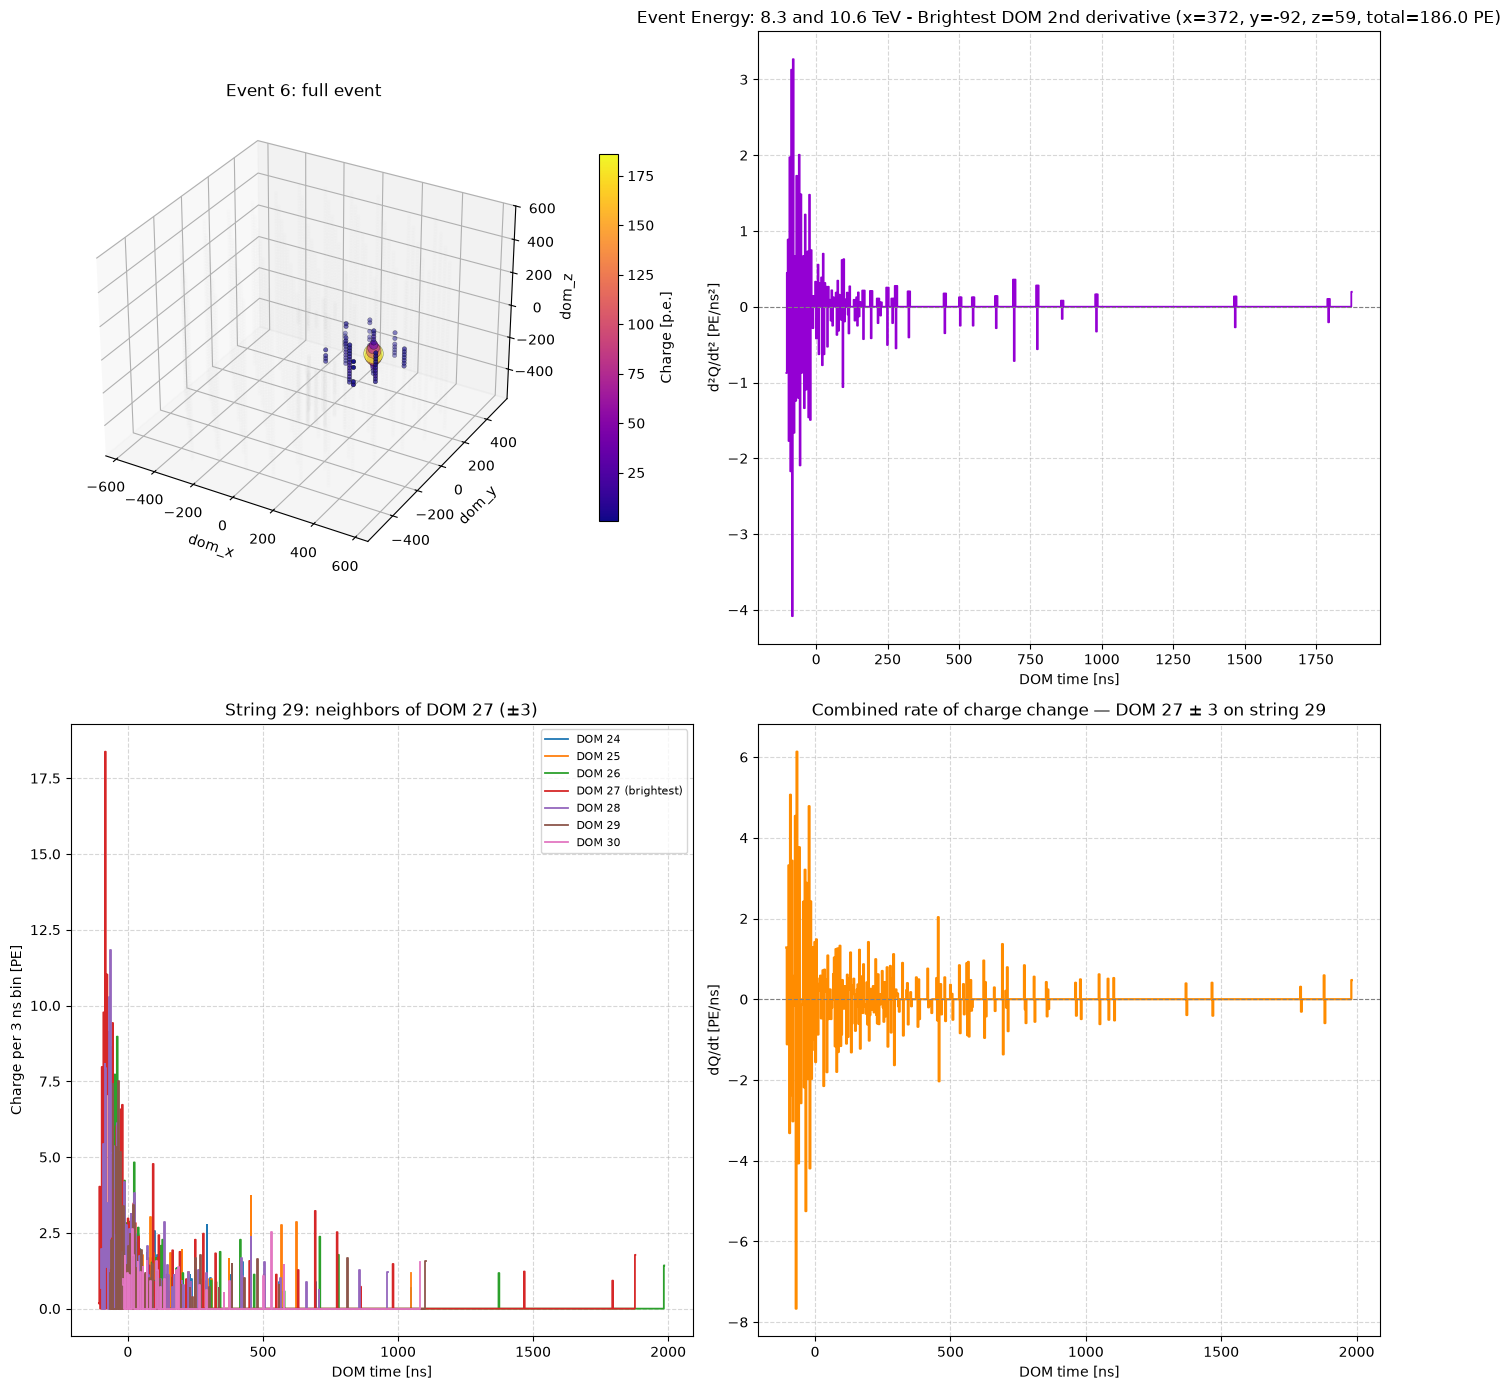

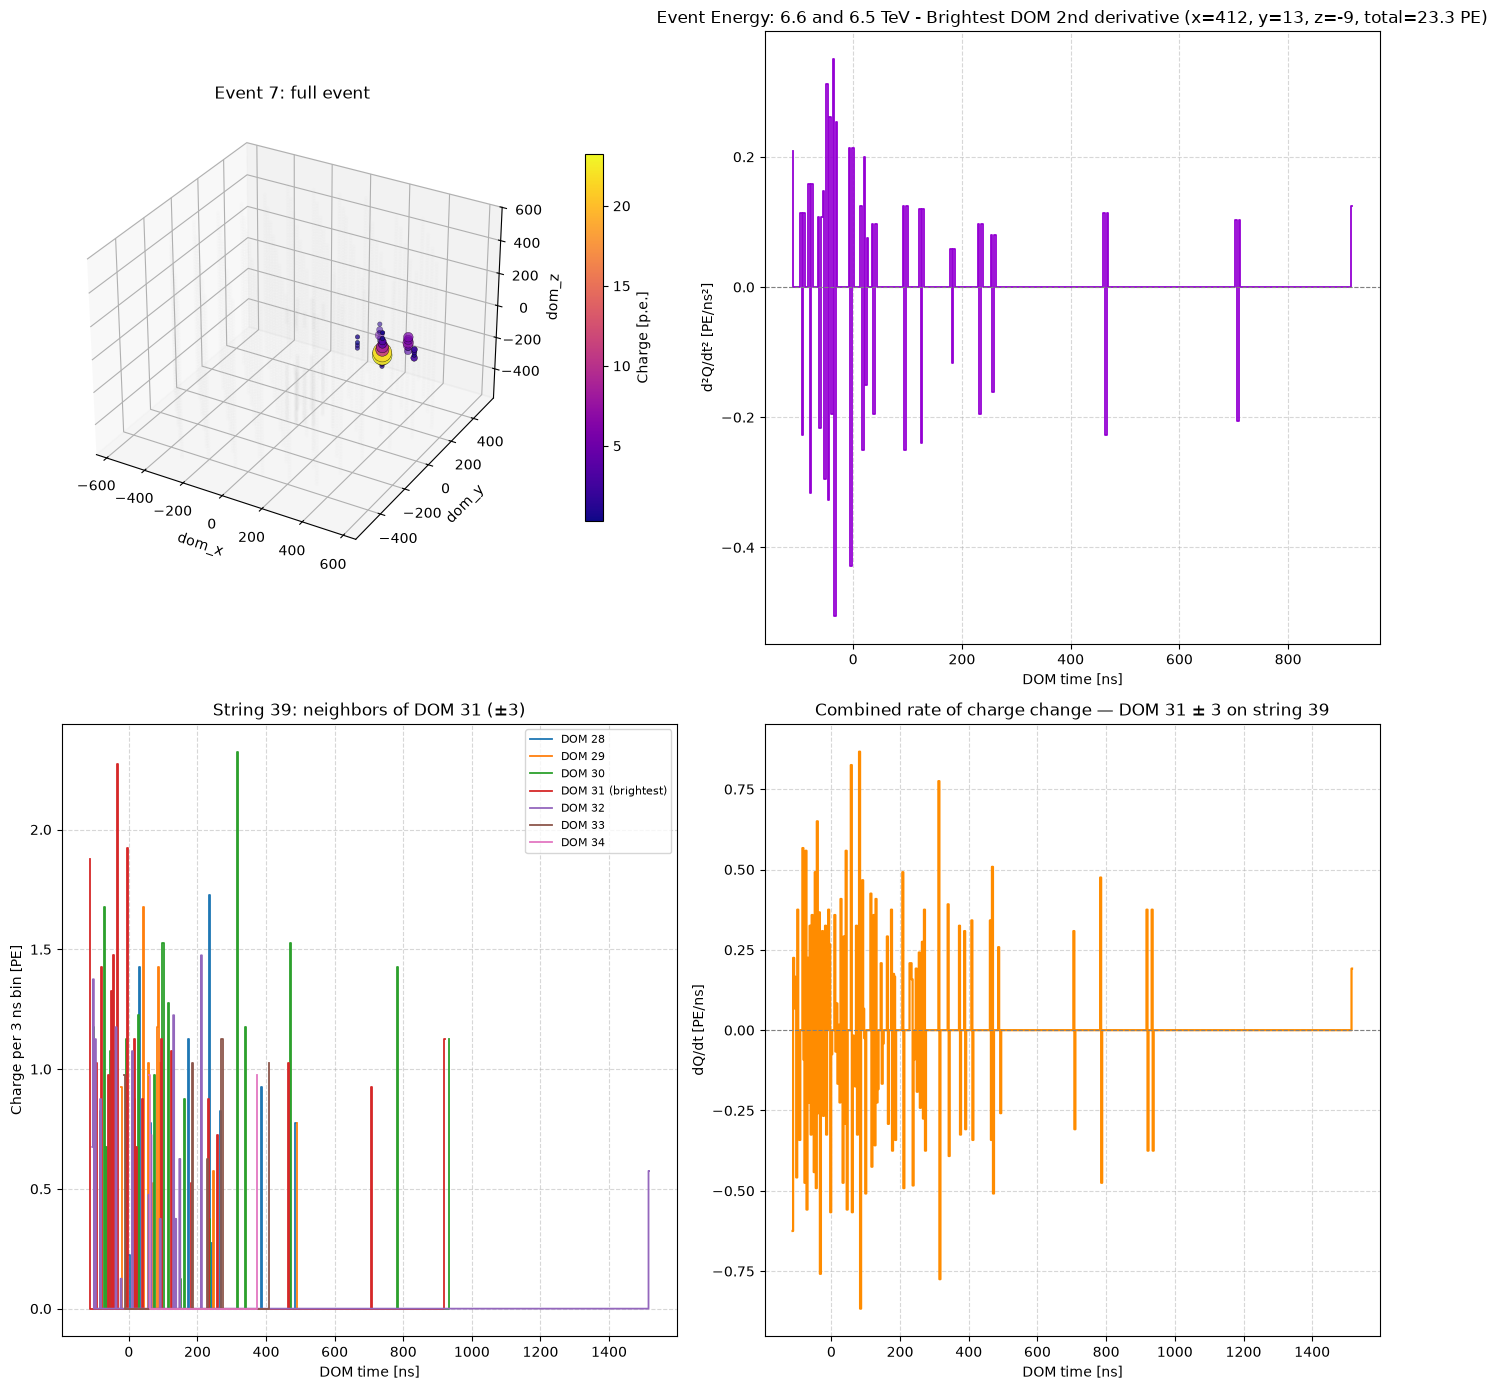

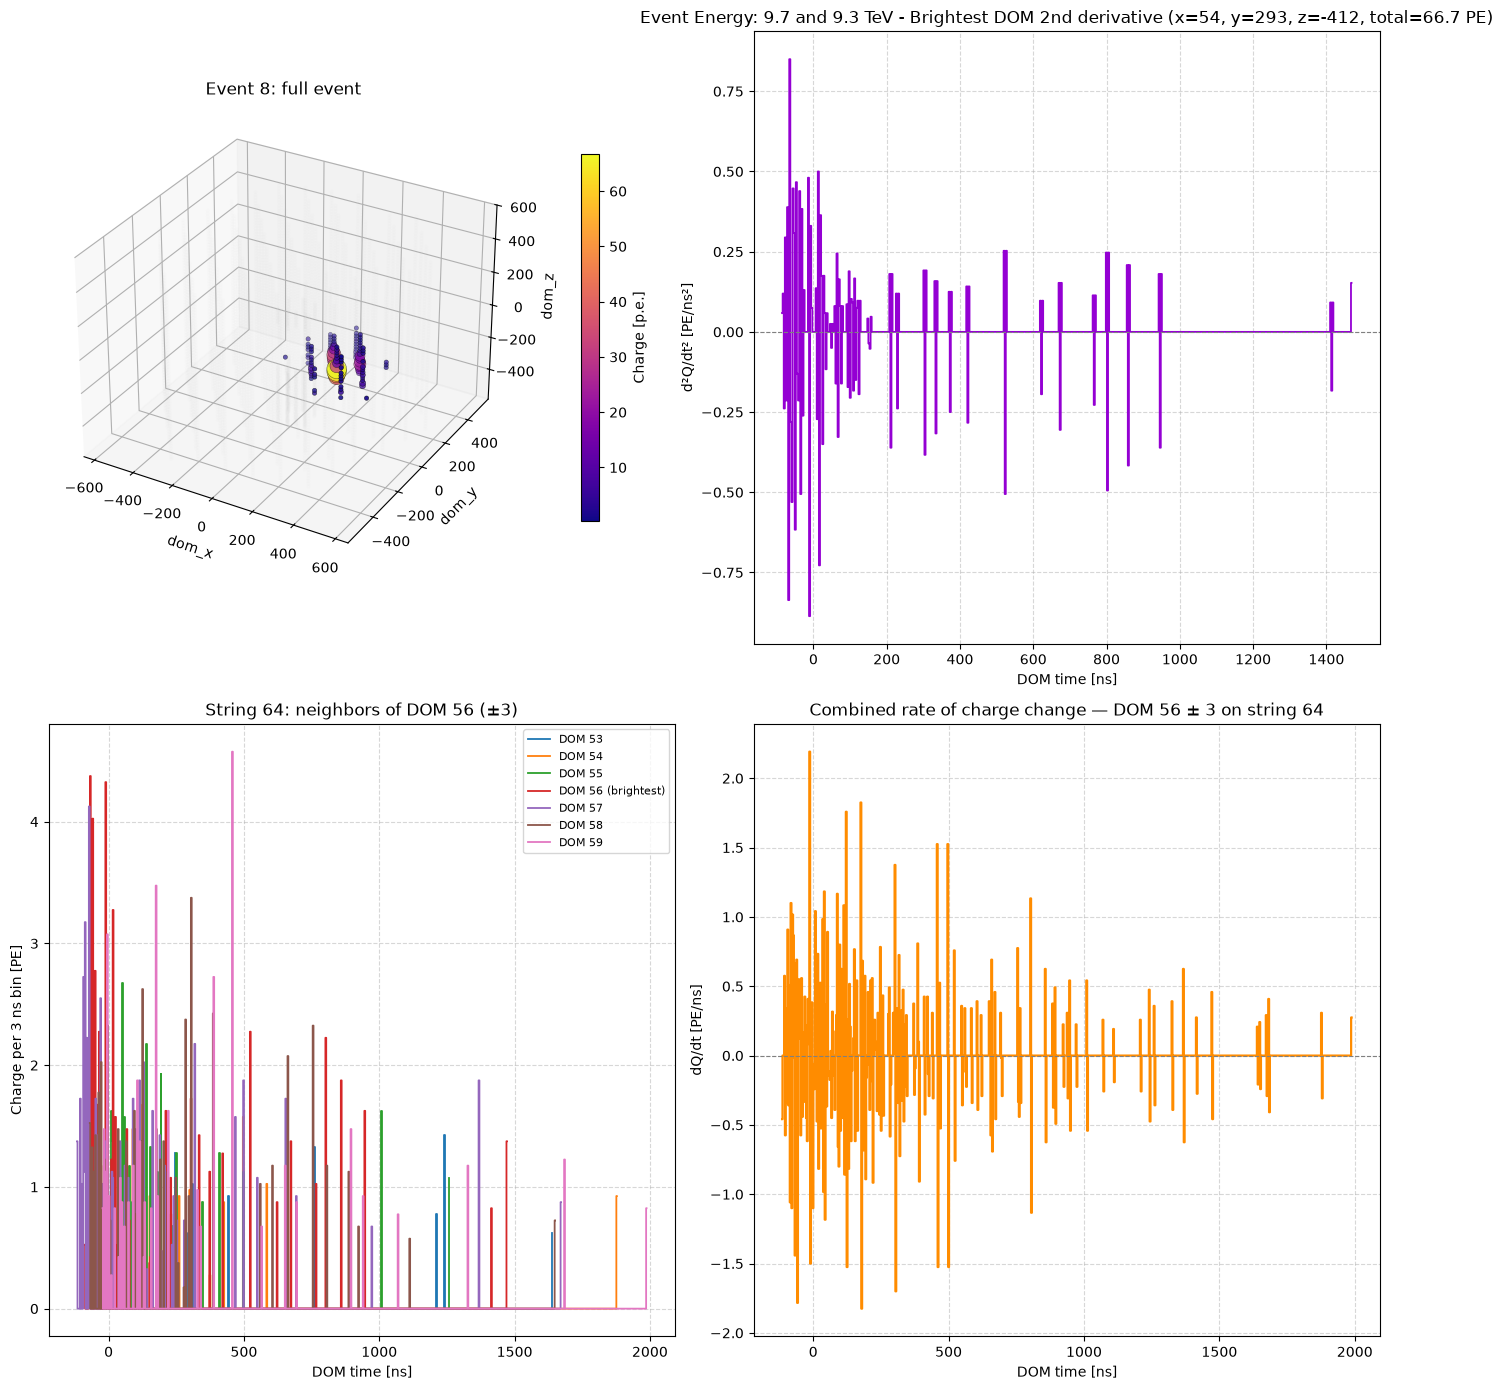

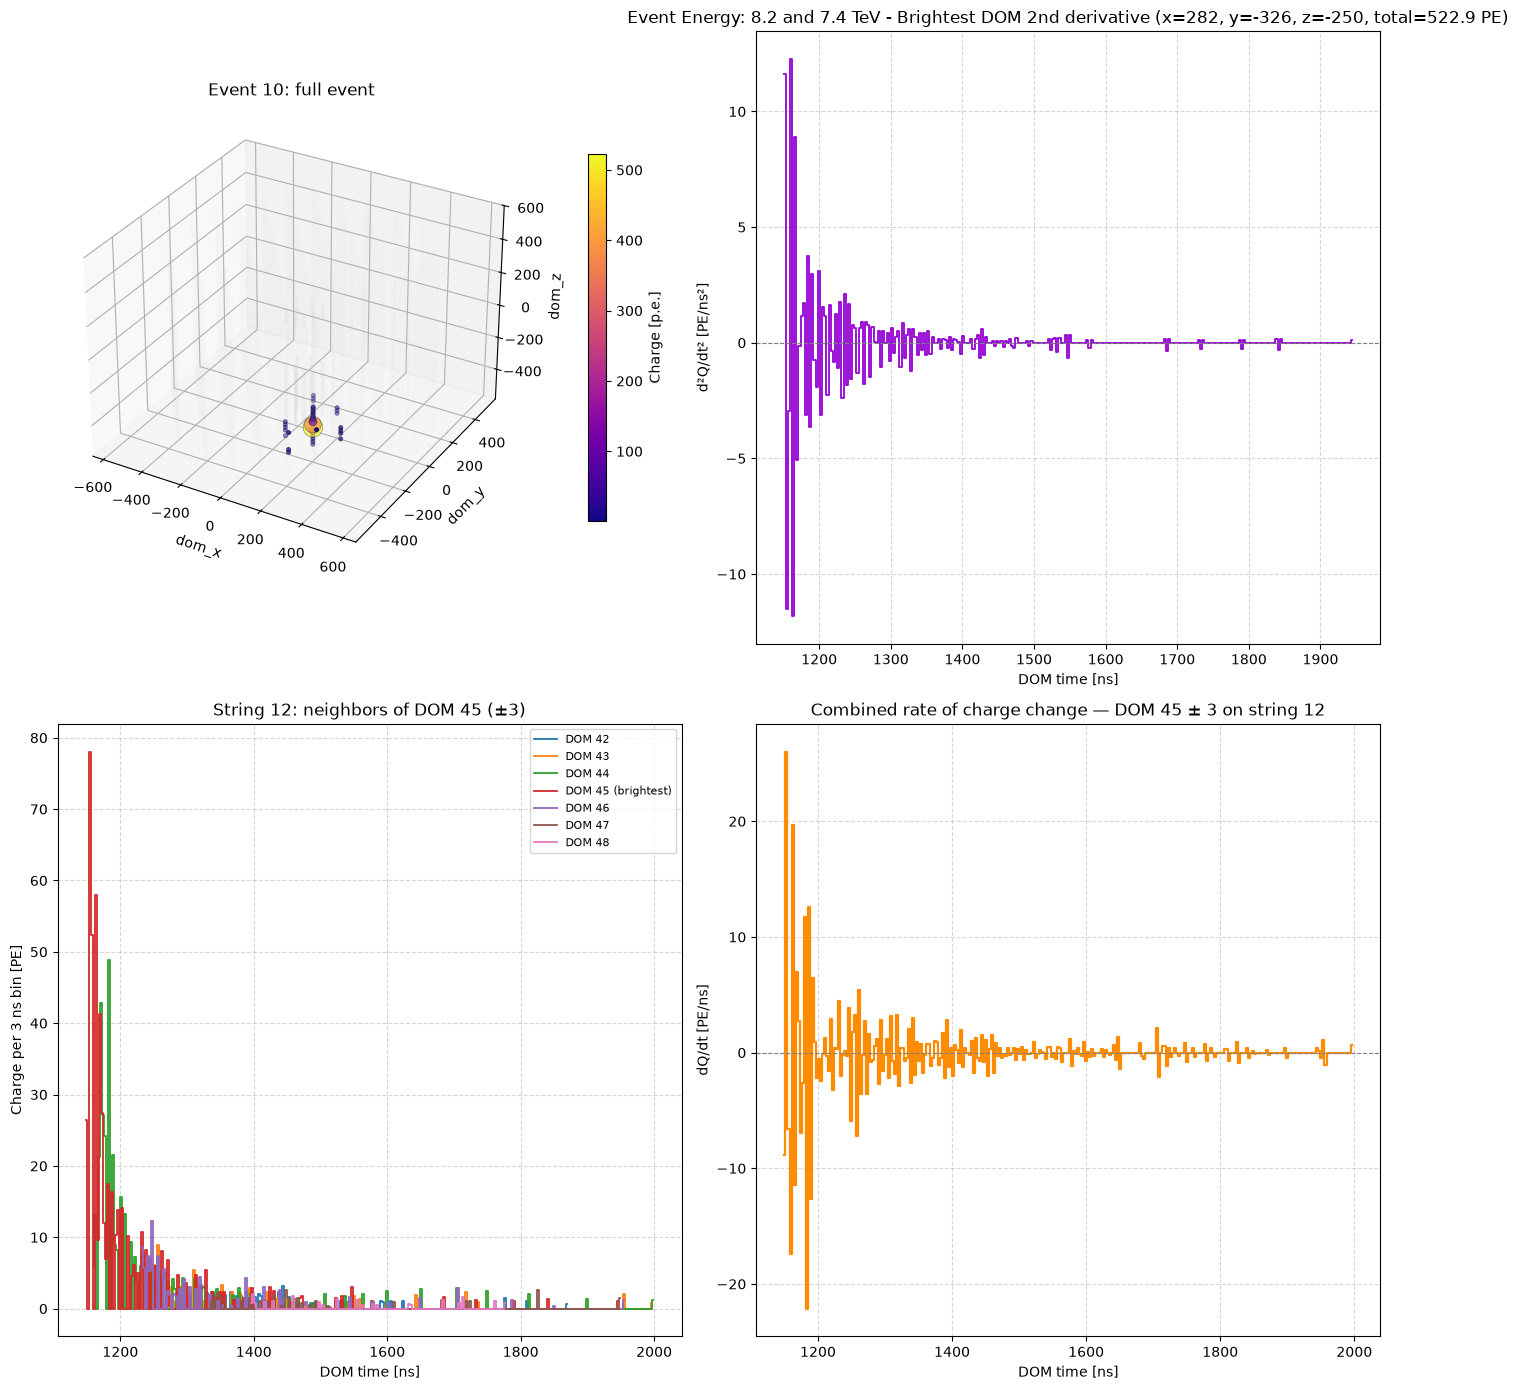

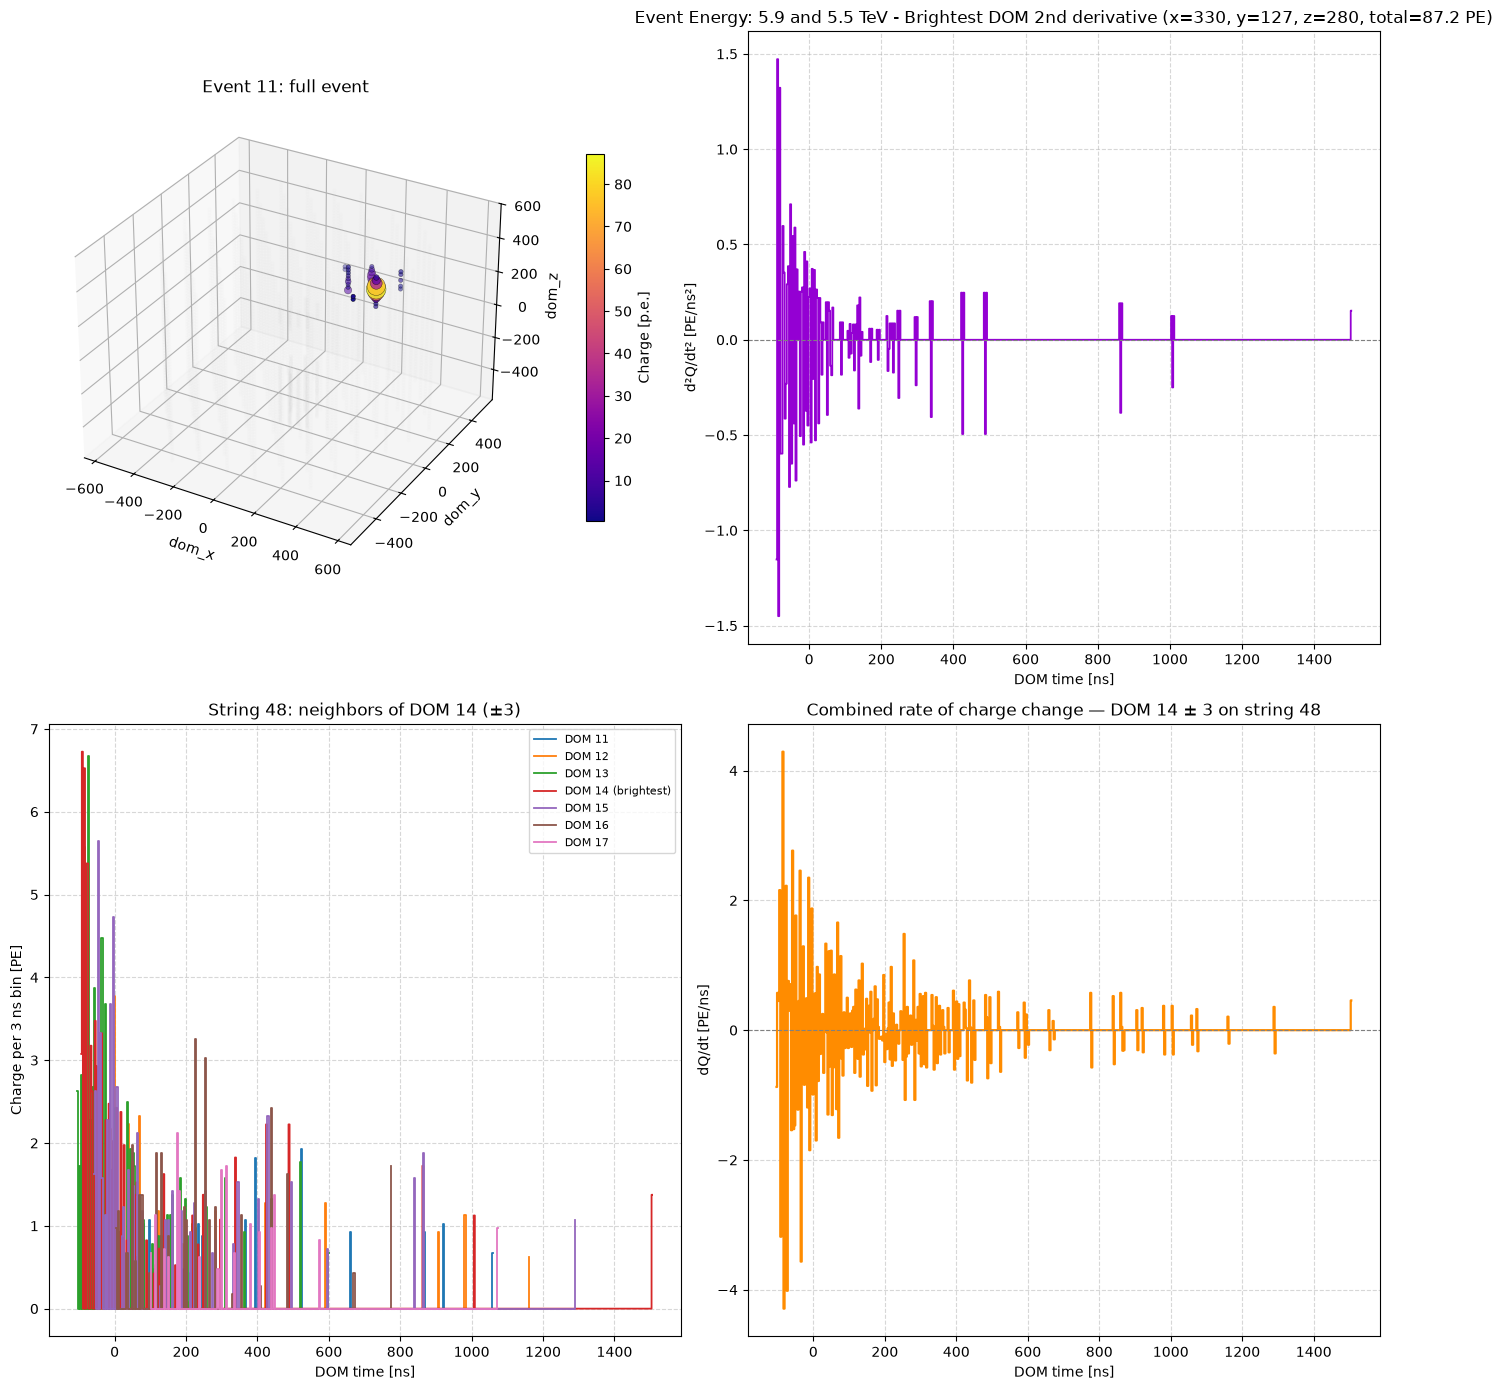

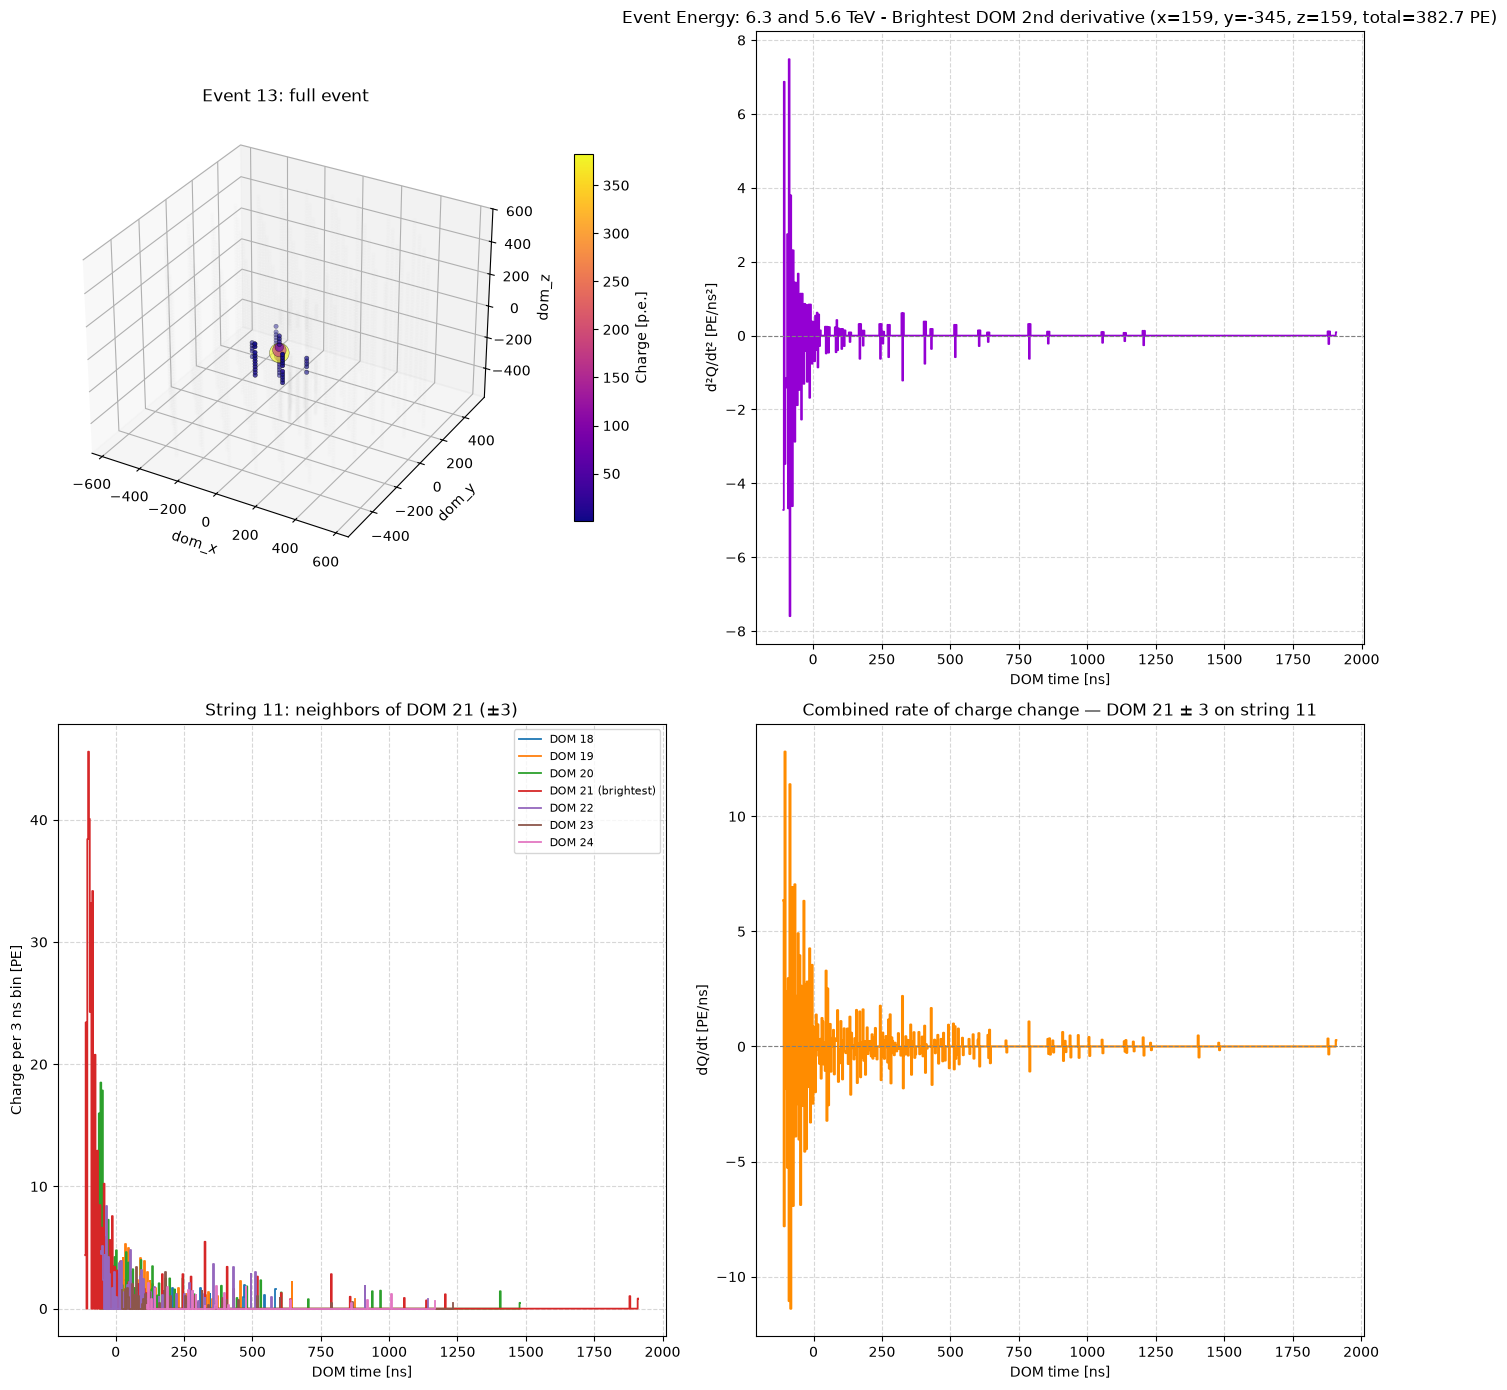

In [22]:
from matplotlib.backends.backend_pdf import PdfPages

charge_thresh_min = 0
charge_thresh_max = 10000
bin_width = 3  # ns
n_neighbors = 3  # DOMs above/below the brightest one on the string

events_to_plot = max_dom_charge_per_event.index[:10]  # or reuse your existing event selection

with PdfPages('100-1000pe_domcut.pdf') as pdf:
    for event_no in events_to_plot:
        df_event = df_pulses[df_pulses['event_no'] == event_no]
        energy = df_truth[df_truth['event_no'] == event_no]['energy'].values[0]
        reco_energy = df_reco[df_reco['event_no'] == event_no]['cascade_reco_energy_tev'].values[0]

        # Sum charge per DOM over the FULL event (no time window / no DOM filtering)
        charge_per_dom = df_event.groupby(['dom_x', 'dom_y', 'dom_z'])['charge'].sum().reset_index()

        if charge_per_dom.empty:
            continue

        # Selection is applied only to the brightest DOM
        brightest_dom = charge_per_dom.loc[charge_per_dom['charge'].idxmax()]
        if not (charge_thresh_min < brightest_dom['charge'] < charge_thresh_max):
            print(f"Event {event_no}: brightest DOM charge {brightest_dom['charge']:.1f} PE outside range ({charge_thresh_min}, {charge_thresh_max}) PE")
            continue

        bx, by, bz = brightest_dom['dom_x'], brightest_dom['dom_y'], brightest_dom['dom_z']
        dom_pulses = df_event[
            (df_event['dom_x'] == bx) &
            (df_event['dom_y'] == by) &
            (df_event['dom_z'] == bz)
        ].sort_values('dom_time')

        # Attach string/dom_no to this event's pulses, and find neighbors of the brightest DOM
        pulses_with_domno = df_event.merge(
            geo[['dom_x', 'dom_y', 'dom_z', 'string', 'dom_no']],
            on=['dom_x', 'dom_y', 'dom_z'], how='left'
        )
        brightest_geo_row = geo[
            (geo['dom_x'] == bx) & (geo['dom_y'] == by) & (geo['dom_z'] == bz)
        ].iloc[0]
        b_string, b_dom_no = brightest_geo_row['string'], brightest_geo_row['dom_no']
        neighbor_range = range(int(b_dom_no - n_neighbors), int(b_dom_no + n_neighbors + 1))
        neighbor_pulses = pulses_with_domno[
            (pulses_with_domno['string'] == b_string) &
            (pulses_with_domno['dom_no'].isin(neighbor_range))
        ]

        # Plot ALL DOMs in the event, not just the selected one
        x, y, z, charge = (charge_per_dom['dom_x'], charge_per_dom['dom_y'],
                            charge_per_dom['dom_z'], charge_per_dom['charge'])

        fig = plt.figure(figsize=(14, 14))

        # Top-left: full event 3D charge map
        ax = fig.add_subplot(221, projection='3d')
        im = ax.scatter(x, y, z, c=charge, s=np.clip(charge / charge.max() * 200, 10, 200),
                        cmap='plasma', edgecolors='k', linewidths=0.3, zorder=100)
        ax.scatter(geo['dom_x'], geo['dom_y'], geo['dom_z'], c='lightgray', s=4, alpha=0.15, zorder=1)
        ax.set_xlabel('dom_x'); ax.set_ylabel('dom_y'); ax.set_zlabel('dom_z')
        ax.set_title(f'Event {event_no}: full event')
        plt.colorbar(im, ax=ax, shrink=0.6, pad=0.1).set_label('Charge [p.e.]')

        # Top-right: SECOND derivative of charge vs time, brightest DOM
        t_min, t_max = dom_pulses['dom_time'].min(), dom_pulses['dom_time'].max()
        bins = np.arange(t_min, t_max + bin_width, bin_width)
        charge_binned, bin_edges = np.histogram(dom_pulses['dom_time'], bins=bins, weights=dom_pulses['charge'])
        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

        dQ_dt_b = np.diff(charge_binned) / bin_width
        dQ_dt_b_centers = 0.5 * (bin_centers[:-1] + bin_centers[1:])

        d2Q_dt2_b = np.diff(dQ_dt_b) / bin_width
        d2Q_dt2_b_centers = 0.5 * (dQ_dt_b_centers[:-1] + dQ_dt_b_centers[1:])

        ax2 = fig.add_subplot(222)
        ax2.plot(d2Q_dt2_b_centers, d2Q_dt2_b, drawstyle='steps-mid', color='darkviolet', linewidth=1.3)
        ax2.axhline(0, color='gray', linewidth=0.8, linestyle='--')
        ax2.set_xlabel('DOM time [ns]')
        ax2.set_ylabel('d²Q/dt² [PE/ns²]')
        ax2.set_title(f'Event Energy: {energy/1e3:.1f} and {reco_energy:.1f} TeV - '
                      f'Brightest DOM 2nd derivative (x={bx:.0f}, y={by:.0f}, z={bz:.0f}, total={brightest_dom["charge"]:.1f} PE)')
        ax2.grid(True, linestyle='--', alpha=0.5)
        # ax2.set_xlim(right=500) 
        # Bottom-left: charge vs time, brightest DOM + its neighbors, overlaid
        ax3 = fig.add_subplot(223)
        neighbor_bins_cache = {}  # keep binned data to reuse for dQ/dt panel
        for dom_no_val in sorted(neighbor_pulses['dom_no'].unique()):
            dp = neighbor_pulses[neighbor_pulses['dom_no'] == dom_no_val].sort_values('dom_time')
            if dp.empty:
                continue
            dt_min, dt_max = dp['dom_time'].min(), dp['dom_time'].max()
            dbins = np.arange(dt_min, dt_max + bin_width, bin_width)
            dbinned, dedges = np.histogram(dp['dom_time'], bins=dbins, weights=dp['charge'])
            dcenters = 0.5 * (dedges[:-1] + dedges[1:])
            neighbor_bins_cache[dom_no_val] = (dcenters, dbinned)
            label = f'DOM {int(dom_no_val)}' + (' (brightest)' if dom_no_val == b_dom_no else '')
            ax3.step(dcenters, dbinned, where='mid', linewidth=1.3, label=label)
        ax3.set_xlabel('DOM time [ns]')
        ax3.set_ylabel(f'Charge per {bin_width} ns bin [PE]')
        ax3.set_title(f'String {int(b_string)}: neighbors of DOM {int(b_dom_no)} (±{n_neighbors})')
        ax3.legend(fontsize=8)
        ax3.grid(True, linestyle='--', alpha=0.5)
        # ax3.set_xlim(right=500)
        # Bottom-right: rate of charge change, all neighboring DOMs overlaid
        # ax4 = fig.add_subplot(224)
        # for dom_no_val, (dcenters, dbinned) in neighbor_bins_cache.items():
        #     if len(dbinned) < 2:
        #         continue
        #     dQ_dt = np.diff(dbinned) / bin_width
        #     dQ_dt_centers = 0.5 * (dcenters[:-1] + dcenters[1:])
        #     label = f'DOM {int(dom_no_val)}' + (' (brightest)' if dom_no_val == b_dom_no else '')
        #     ax4.plot(dQ_dt_centers, dQ_dt, drawstyle='steps-mid', linewidth=1.2, label=label)
        # ax4.axhline(0, color='gray', linewidth=0.8, linestyle='--')
        # ax4.set_xlabel('DOM time [ns]')
        # ax4.set_ylabel('dQ/dt [PE/ns]')
        # ax4.set_title('Rate of charge change — neighboring DOMs')
        # ax4.legend(fontsize=8)
        # ax4.grid(True, linestyle='--', alpha=0.5)
        # ax4.set_xlim(right=500)
                # Bottom-right: COMBINED rate of change of charge — brightest DOM + neighbors summed together
        ax4 = fig.add_subplot(224)

        # Bin ALL neighbor pulses (including brightest) together by time, summing charge across DOMs
        t_min_all, t_max_all = neighbor_pulses['dom_time'].min(), neighbor_pulses['dom_time'].max()
        combined_bins = np.arange(t_min_all, t_max_all + bin_width, bin_width)
        combined_charge_binned, combined_bin_edges = np.histogram(
            neighbor_pulses['dom_time'], bins=combined_bins, weights=neighbor_pulses['charge']
        )
        combined_bin_centers = 0.5 * (combined_bin_edges[:-1] + combined_bin_edges[1:])

        dQ_dt_combined = np.diff(combined_charge_binned) / bin_width
        dQ_dt_combined_centers = 0.5 * (combined_bin_centers[:-1] + combined_bin_centers[1:])

        ax4.plot(dQ_dt_combined_centers, dQ_dt_combined, drawstyle='steps-mid',
                  color='darkorange', linewidth=1.6)
        ax4.axhline(0, color='gray', linewidth=0.8, linestyle='--')
        ax4.set_xlabel('DOM time [ns]')
        ax4.set_ylabel('dQ/dt [PE/ns]')
        ax4.set_title(f'Combined rate of charge change — DOM {int(b_dom_no)} ± {n_neighbors} on string {int(b_string)}')
        ax4.grid(True, linestyle='--', alpha=0.5)
        # ax4.set_xlim(right=500)
        # pdf.savefig(fig)
        plt.tight_layout()
        plt.show()
        plt.close(fig)

In [ ]:
event_no = 3  # set to the event you want
for i in np.arange(1, 10):
    event_no = i
    df_event = df_pulses[df_pulses['event_no'] == event_no]

    charge_per_dom = df_event.groupby(['dom_x', 'dom_y', 'dom_z'])['charge'].sum().reset_index()
    x, y, z, charge = charge_per_dom['dom_x'], charge_per_dom['dom_y'], charge_per_dom['dom_z'], charge_per_dom['charge']

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    im = ax.scatter(x, y, z, c=charge, s=np.clip(charge / charge.max() * 200, 10, 200),
                    cmap='plasma', edgecolors='k', linewidths=0.3, zorder=100)
    ax.set_xlabel('dom_x')
    ax.set_ylabel('dom_y')
    ax.set_zlabel('dom_z')
    ax.set_title(f'Event {event_no}: DOM charge')

    cbar = plt.colorbar(im, ax=ax, shrink=0.6, pad=0.1)
    cbar.set_label('Charge [p.e.]')

    plt.show()

In [ ]:
event_no = 1  # set to the event you want

for i in np.arange(1, 10):
    event_no = i
    df_event = df_pulses[df_pulses['event_no'] == event_no]

    dom_stats = df_event.groupby(['dom_x', 'dom_y', 'dom_z']).apply(
        lambda g: pd.Series({
            'charge': g['charge'].sum(),
            't_mean': np.average(g['dom_time'], weights=g['charge']),  # charge-weighted mean hit time
        })
    ).reset_index()

    x, y, z = dom_stats['dom_x'], dom_stats['dom_y'], dom_stats['dom_z']
    charge, t_mean = dom_stats['charge'], dom_stats['t_mean']

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    im = ax.scatter(x, y, z, c=t_mean, s=np.clip(charge / charge.max() * 200, 10, 200),
                    cmap='viridis', edgecolors='k', linewidths=0.3, zorder=100)
    ax.set_xlabel('dom_x')
    ax.set_ylabel('dom_y')
    ax.set_zlabel('dom_z')
    ax.set_title(f'Event {event_no}: DOM hit time (size = charge)')

    cbar = plt.colorbar(im, ax=ax, shrink=0.6, pad=0.1)
    cbar.set_label('Time [ns]')

    plt.show()

In [ ]:
# Strings are identified by DOMs sharing the same (dom_x, dom_y); dom_z varies along a string.
charge_per_string = (df_redpulses
                      .groupby(['dom_x', 'dom_y'])['charge']
                      .sum()
                      .sort_values(ascending=False))

brightest_x, brightest_y = charge_per_string.index[0]
brightest_total_charge = charge_per_string.iloc[0]

string_pulses = (df_redpulses[(df_redpulses['dom_x'] == brightest_x) &
                               (df_redpulses['dom_y'] == brightest_y)]
                  .sort_values('dom_time')
                  .reset_index(drop=True))

print(f"event_no = {dfrow['event_no']}")
print(f"n_strings_hit = {len(charge_per_string)}")
print(f"brightest string: dom_x={brightest_x}, dom_y={brightest_y}, "
      f"total charge = {brightest_total_charge:.2f} p.e., "
      f"n_doms_on_string = {string_pulses['dom_z'].nunique()}, "
      f"n_pulses_on_string = {len(string_pulses)}")

string_pulses

In [ ]:
import matplotlib.colors as colors
fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(string_pulses['dom_time'], string_pulses['charge'],
                 c=string_pulses['dom_z'], cmap='viridis', #norm=colors.LogNorm(),
                 s=60, edgecolors='k', linewidths=0.5)
ax.set_xlabel('hit time [ns]')
ax.set_ylabel('charge [p.e.]')
ax.set_yscale('log')
ax.set_title(f"Charge vs hit time — brightest string "
             f"(x={brightest_x:.1f}, y={brightest_y:.1f}), event_no={dfrow['event_no']}")
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('dom_z [m]  (depth along string)')
plt.tight_layout()
plt.show()

In [ ]:
def brightest_string_pulses(event_no):
    dfrow = df[df['event_no'] == event_no].iloc[0]
    ev_pulses = pd.DataFrame({
        'dom_x': dfrow['dom_x'], 'dom_y': dfrow['dom_y'], 'dom_z': dfrow['dom_z'],
        'charge': dfrow['charge'], 'dom_time': dfrow['dom_time'],
    })
    charge_per_string = ev_pulses.groupby(['dom_x', 'dom_y'])['charge'].sum().sort_values(ascending=False)
    bx, by = charge_per_string.index[0]
    string_pulses = (ev_pulses[(ev_pulses['dom_x'] == bx) & (ev_pulses['dom_y'] == by)]
                      .sort_values('dom_time')
                      .reset_index(drop=True))
    return string_pulses, bx, by, charge_per_string.iloc[0]

event_no = df['event_no'].iloc[0]  # <- set the event to analyze

string_pulses, bx, by, total_q = brightest_string_pulses(event_no)

charge_per_dom_on_string = (string_pulses
                             .groupby('dom_z')['charge']
                             .sum()
                             .sort_index())

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(charge_per_dom_on_string.index, charge_per_dom_on_string.values, width=5)
ax.set_xlabel('dom_z [m]')
ax.set_ylabel('total charge [p.e.]')
ax.set_title(f'Charge per DOM — brightest string (x={bx:.0f}, y={by:.0f}), event {event_no}, Q_tot={total_q:.1f} p.e.')
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.colors as colors
fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(string_pulses['dom_time'], string_pulses['charge'],
                 c=string_pulses['dom_z'], cmap='viridis',# norm=colors.LogNorm(),
                 s=60, edgecolors='k', linewidths=0.5)
ax.set_xlabel('hit time [ns]')
ax.set_ylabel('charge [p.e.]')
ax.set_yscale('log')
ax.set_title(f"Charge vs hit time — brightest string "
             f"(x={brightest_x:.1f}, y={brightest_y:.1f}), event_no={dfrow['event_no']}")
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('dom_z [m]  (depth along string)')
plt.tight_layout()
plt.show()

In [ ]:
n_events = 10
charge_threshold = 0  # p.e. — drop any dom_z with a hit below this

event_list = df['event_no'].iloc[:n_events].tolist()

def brightest_string_pulses(event_no):
    dfrow = df[df['event_no'] == event_no].iloc[0]
    ev_pulses = pd.DataFrame({
        'dom_x': dfrow['dom_x'], 'dom_y': dfrow['dom_y'], 'dom_z': dfrow['dom_z'],
        'charge': dfrow['charge'], 'dom_time': dfrow['dom_time'],
    })
    charge_per_string = ev_pulses.groupby(['dom_x', 'dom_y'])['charge'].sum().sort_values(ascending=False)
    bx, by = charge_per_string.index[0]
    string_pulses = (ev_pulses[(ev_pulses['dom_x'] == bx) & (ev_pulses['dom_y'] == by)]
                      .sort_values('dom_time')
                      .reset_index(drop=True))
    return string_pulses, bx, by, charge_per_string.iloc[0]

n = len(event_list)
fig, axes = plt.subplots(1, n, figsize=(6 * n, 5), sharey=False)
if n == 1:
    axes = [axes]

for ax, ev in zip(axes, event_list):
    string_pulses, bx, by, total_q = brightest_string_pulses(ev)

    min_charge_per_dom = string_pulses.groupby('dom_z')['charge'].min()
    keep_doms = min_charge_per_dom[min_charge_per_dom >= charge_threshold].index
    string_pulses = string_pulses[string_pulses['dom_z'].isin(keep_doms)].reset_index(drop=True)

    shifted = string_pulses.copy()
    shifted['dom_time'] = string_pulses['dom_time'] - string_pulses['dom_time'].min()

    ax.plot(shifted['dom_time'], shifted['charge'], '-o', color='0.4', zorder=1)
    sc = ax.scatter(shifted['dom_time'], shifted['charge'],
                     c=string_pulses['dom_z'], cmap='viridis',
                     s=60, edgecolors='k', linewidths=0.5, zorder=2)
    ax.set_xlabel('time since first hit on string [ns]')
    # ax.set_yscale('log')
    ax.set_title(f"event {ev}\nstring (x={bx:.0f}, y={by:.0f}), Q={total_q:.1f} p.e.")
    fig.colorbar(sc, ax=ax, label='dom_z [m]')
    ax.set_xlim(right=1000)

axes[0].set_ylabel('charge [p.e.]')
plt.tight_layout()
plt.show()

In [ ]:
def brightest_string_pulses(event_no):
    dfrow = df[df['event_no'] == event_no].iloc[0]
    ev_pulses = pd.DataFrame({
        'dom_x': dfrow['dom_x'], 'dom_y': dfrow['dom_y'], 'dom_z': dfrow['dom_z'],
        'charge': dfrow['charge'], 'dom_time': dfrow['dom_time'],
    })
    charge_per_string = ev_pulses.groupby(['dom_x', 'dom_y'])['charge'].sum().sort_values(ascending=False)
    bx, by = charge_per_string.index[0]
    string_pulses = (ev_pulses[(ev_pulses['dom_x'] == bx) & (ev_pulses['dom_y'] == by)]
                      .sort_values('dom_time')
                      .reset_index(drop=True))
    return string_pulses, bx, by, charge_per_string.iloc[0]

n_events = 8
charge_threshold_event = 0

event_list = []
for ev in df['event_no']:
    _, _, _, total_q = brightest_string_pulses(ev)
    if total_q > charge_threshold_event:
        event_list.append(ev)
    if len(event_list) == n_events:
        break

print(f"selected {len(event_list)} events with brightest-string charge > {charge_threshold_event} p.e.: {event_list}")

charge_threshold = 0  # p.e. — drop any dom_z with a hit below this

n = len(event_list)
fig, axes = plt.subplots(1, n, figsize=(6 * n, 5), sharey=False)
if n == 1:
    axes = [axes]

for ax, ev in zip(axes, event_list):
    string_pulses, bx, by, total_q = brightest_string_pulses(ev)

    min_charge_per_dom = string_pulses.groupby('dom_z')['charge'].min()
    keep_doms = min_charge_per_dom[min_charge_per_dom >= charge_threshold].index
    string_pulses = string_pulses[string_pulses['dom_z'].isin(keep_doms)].reset_index(drop=True)

    shifted = string_pulses.copy()
    shifted['dom_time'] = string_pulses['dom_time'] - string_pulses['dom_time'].min()

    ax.plot(shifted['dom_time'], shifted['charge'], '-o', color='0.4', zorder=1)
    sc = ax.scatter(shifted['dom_time'], shifted['charge'],
                     c=string_pulses['dom_z'], cmap='viridis',
                     s=60, edgecolors='k', linewidths=0.5, zorder=2)
    ax.set_xlabel('time since first hit on string [ns]')
    ax.set_yscale('log')
    ax.set_title(f"event {ev}\nstring (x={bx:.0f}, y={by:.0f}), Q={total_q:.1f} p.e.")
    fig.colorbar(sc, ax=ax, label='dom_z [m]')
    ax.set_xlim(right=500)

axes[0].set_ylabel('charge [p.e.]')
plt.tight_layout()
plt.show()